# Exploratory Data Analysis - CBIS-DDSM Mass Cases

**Chollet Workflow Stages 1-3**

This notebook explores the CBIS-DDSM **mass** training and test sets - calcification cases are outside the scope of this study. The goal is to understand class distribution, patient coverage, view availability, and image characteristics before any modelling work begins.

**Dataset references:**

Lee, R., Gimenez, F., Hoogi, A., Miyake, K. K., Gorovoy, M. & Rubin, D. L. (2017). A curated mammography data set for use in computer-aided detection and diagnosis research. *Scientific Data*, 4, 170177. https://doi.org/10.1038/sdata.2017.177

Wang, L. (2024). Mammography with deep learning for breast cancer detection. *Frontiers in Oncology*, 14, 1281922. https://doi.org/10.3389/fonc.2024.1281922

Chollet, F. (2018). *Deep Learning with Python*. Manning.

American College of Radiology (2013). *ACR BI-RADS Atlas: Breast Imaging Reporting and Data System* (5th ed.). American College of Radiology.

NHS England (2022). *Breast Screening Programme, England 2019-20*. NHS Digital.

McKinney, S. M. et al. (2020). International evaluation of an AI system for breast cancer screening. *Nature*, 577, 89-94.

---

## Notebook structure

| Section | Purpose |
|---|---|
| 0. Setup | Seeds, paths, imports |
| 1. Load & inspect | CSV shape, columns, dtypes |
| 2. Missing values | Identify gaps; duplicate image paths |
| 3. Patient-level leakage check | Verify train/test patients are disjoint |
| 4. Class distribution | Label balance; BENIGN_WITHOUT_CALLBACK analysis; real-world prevalence enrichment |
| 5. Clinical features | Mass shape, margins, assessment, subtlety - chi-square + Cramér's V + Mann-Whitney U |
| 5b. Breast density | ACR density distribution; association with malignancy; Phase 9 stratification note |
| 5c. BI-RADS clinical baseline | BI-RADS ROC curve; threshold sensitivity/specificity; radiologist-pathology discordance |
| 6. View coverage | CC / MLO availability; multi-view pairing structure for Phase 7 |
| 7. Sample images | Visual inspection with pathology labels |
| 8. DICOM metadata audit | Bit depth, photometric interpretation (full audit) |
| 9. Image resolution | Height/width distributions; resize justification |
| 10. Pixel intensity | Histogram; class-stratified statistics |
| 10a. Normalisation statistics | Training-set mean/std; normalisation decision; ImageNet constants |
| 10b. Augmentation preview | Visual confirmation of training augmentation pipeline |
| 11. EDA summary | Dataset characterisation; preprocessing implications |

## 0. Setup

Seeds are fixed here and must match across all notebooks in this project. All paths and constants live in `CONFIG` - no magic numbers elsewhere in the notebook.

In [1]:
import os
import random
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import scipy.ndimage as ndi
import seaborn as sns
from PIL import Image as _PIL_Image
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from src import config
from src.data_loader import _prepare_frame, _pool_frames, _three_way_split

SEED = config.SEED
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

CONFIG = {
    "seed": SEED,
    # Paths/fractions/size pulled from config.py - single source of truth,
    # removes the drift risk that let Section 3b diverge from Section 1.
    "train_csv": config.TRAIN_CSV,
    "test_csv": config.TEST_CSV,
    "train_img_dir": config.TRAIN_IMG_DIR,
    "test_img_dir": config.TEST_IMG_DIR,
    "figures_dir": config.FIGURES_DIR / "eda",
    "cat_cols": [
        "left or right breast",
        "image view",
        "pathology",
        "mass shape",
        "mass margins",
    ],
    "img_col": "image file path",
    "clinical_cols": ["mass shape", "mass margins", "assessment", "subtlety"],
    "valid_views": ["CC", "MLO"],
     "target_size": config.TARGET_SIZE,
    "test_fraction": config.TEST_FRACTION,
    "val_fraction": config.VAL_FRACTION,
}

# Validate paths exist before any downstream cell can fail silently
for _key in ("train_csv", "test_csv", "train_img_dir", "test_img_dir"):
    assert CONFIG[
        _key
    ].exists(), f"Expected path not found - CONFIG['{_key}']: {CONFIG[_key]}"

CONFIG["figures_dir"].mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "figure.figsize": (10, 6),
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "savefig.bbox": "tight",
        "savefig.dpi": 150,
    }
)

print(f"numpy {np.__version__}")
print(f"pandas {pd.__version__}")
print(f"pydicom {pydicom.__version__}")

numpy 1.26.4
pandas 3.0.2
pydicom 3.0.2


2026-06-26 14:22:54.999474: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-06-26 14:22:54.999555: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-06-26 14:22:54.999561: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-06-26 14:22:54.999583: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-26 14:22:54.999596: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 1. Load & inspect

### Problem definition (Chollet, 2018, Ch. 4)

- **Input**: A single mammogram image (DICOM), representing one view of one breast.
- **Output**: A binary label - malignant (1) or benign/BENIGN_WITHOUT_CALLBACK (0).
- **Task type**: Binary image classification.
- **Why this framing is appropriate**: The unit of analysis is the mammogram image, but the unit of independence is the patient. Multiple rows in the DDSM CSV may share a patient_id. Patient-level stratification is therefore mandatory at the splitting stage to prevent data leakage (Chollet, 2018, Ch. 4).
- **Scope**: Mass cases only. Calcification cases are excluded.

In [2]:
raw_train = pd.read_csv(CONFIG["train_csv"])
raw_test = pd.read_csv(CONFIG["test_csv"])

if set(raw_train.columns) != set(raw_test.columns):
    print("WARNING - column mismatch between train and test:")
    print("train only:", set(raw_train.columns) - set(raw_test.columns))
    print("test only: ", set(raw_test.columns) - set(raw_train.columns))

for col in CONFIG["cat_cols"]:
    for df in [raw_train, raw_test]:
        if col in df.columns:
            df[col] = df[col].astype("category")
        else:
            print(f"WARNING: expected column '{col}' not found")

prepared_train = _prepare_frame(CONFIG["train_csv"])
prepared_test = _prepare_frame(CONFIG["test_csv"])
pool_frame = _pool_frames(prepared_train, prepared_test)

train_split, val_split, test_split = _three_way_split(
    pool_frame,
    test_fraction=CONFIG["test_fraction"],
    val_fraction=CONFIG["val_fraction"],
    seed=CONFIG["seed"]
)

# raw_pool keeps one row per image purely for the descriptive columns (mass
# shape/margins/assessment/subtlety/breast_density). drop_duplicates() here
# picks an arbitrary row when an image has multiple abnormality entries -
# fine for descriptive fields, but NOT the source of truth for the label.
raw_pool = pd.concat([raw_train, raw_test], ignore_index=True).drop_duplicates(subset=['image file path'])

# The authoritative label is the one _prepare_frame/_pool_frames already
# computed (max() across abnormalities, malignant wins) - the same label
# used to stratify the split, and the same one data_loader.py will use to
# train the model. Carrying it through here (rather than re-deriving it
# from raw_pool's 'pathology' column later, in Section 4) guarantees
# train_df/val_df/test_df's label always matches the model-facing label,
# even for the handful of images where the arbitrarily-kept duplicate's
# pathology would otherwise disagree with the max-aggregated truth.
train_df = pd.merge(train_split[['image file path', 'label']], raw_pool, on='image file path', how='inner')
val_df   = pd.merge(val_split[['image file path', 'label']], raw_pool, on='image file path', how='inner')
test_df  = pd.merge(test_split[['image file path', 'label']], raw_pool, on='image file path', how='inner')

# Quantify the actual size of this issue rather than leaving it implicit:
# how many images have a raw 'pathology' that disagrees with the
# authoritative max-aggregated 'label'.
_label_map_check = {"MALIGNANT": 1, "BENIGN": 0, "BENIGN_WITHOUT_CALLBACK": 0}
for _name, _df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    _disagree = (_df["pathology"].map(_label_map_check) != _df["label"]).sum()
    if _disagree:
        print(f"[label check] {_name}: {_disagree} image(s) where raw 'pathology' "
              f"disagrees with the authoritative label (multi-abnormality "
              f"images with mixed benign/malignant findings)")

print("\n=== STRICT 3-WAY SPLIT SUMMARY ===")
print(f"Total Pooled Images: {len(pool_frame)}")
print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

print("\n--- Numeric summary (Strict Train Split) ---")
display(train_df.describe())

print("\n--- First 5 rows (Strict Train Split) ---")
display(train_df.head())

[data_loader] mass_case_description_train_set.csv: dropped 87 duplicate rows (1318 -> 1231 unique images)
[data_loader] mass_case_description_test_set.csv: dropped 17 duplicate rows (378 -> 361 unique images)
[label check] Train: 3 image(s) where raw 'pathology' disagrees with the authoritative label (multi-abnormality images with mixed benign/malignant findings)
[label check] Val: 4 image(s) where raw 'pathology' disagrees with the authoritative label (multi-abnormality images with mixed benign/malignant findings)

=== STRICT 3-WAY SPLIT SUMMARY ===
Total Pooled Images: 1592
Train size: 1134 | Val size: 230 | Test size: 228

--- Numeric summary (Strict Train Split) ---


,label,breast_density,abnormality id,assessment,subtlety
count,1134.000000,1134.000000,1134.000000,1134.000000,1134.000000
mean,0.469136,2.292769,1.012346,3.509700,3.902998
std,0.499267,0.871638,0.125437,1.433243,1.108154
min,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,1.000000,3.000000,3.000000
50%,0.000000,2.000000,1.000000,4.000000,4.000000
75%,1.000000,3.000000,1.000000,4.000000,5.000000
max,1.000000,4.000000,3.000000,5.000000,5.000000



--- First 5 rows (Strict Train Split) ---


,image file path,label,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,cropped image file path,ROI mask file path
0,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,1,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,0,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,0,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,0,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


## 2. Missing Values

### Missing values
`mass margins` (41 train, 7 val, 2 test) and `mass shape` (3 train, 0 val, 0 test) contain missing values inherited from the original DDSM `.OVERLAY` files, in which BI-RADS descriptors were not always recorded at the time of digitisation (Lee et al., 2017). These gaps affect Section 5 clinical feature analysis only - they do not impede the CNN pipeline since model input is the raw image.

### Duplicate image paths
87 training rows and 17 test rows share an image file path with at least one other row. This is intentional dataset design: the `abnormality_id` column exists precisely because a single mammogram may contain multiple distinct masses (Lee et al., 2017). Of the 3,103 mammograms in the full CBIS-DDSM, 465 contain more than one abnormality. `data_loader.py` must deduplicate on `image file path` before constructing any image generator.

In [3]:
for label, df in [("Training", train_df), ("Validation", val_df), ("Test", test_df)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"=== Missing Values - {label} Set ===")
    print(missing.to_string() if not missing.empty else "  No missing values")
    print()

IMG_COL = CONFIG["img_col"]

# Should be 0 in all three - dedup already happened in Section 1.
if IMG_COL in train_df.columns:
    for label, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        n_dup = df[IMG_COL].dropna().duplicated().sum()
        print(f"Duplicate image paths - {label:<5}: {n_dup}")
        if n_dup > 0:
            print(f"\nUNEXPECTED - sample duplicates in {label}:")
            dup_mask = df[IMG_COL].duplicated(keep=False)
            display(
                df[dup_mask][["patient_id", "abnormality id", IMG_COL, "pathology"]]
                .sort_values(IMG_COL)
                .head(6)
            )

# Combined lookup - a pooled row may live in either directory.
_train_dirs_on_disk = {
    p.parent.relative_to(CONFIG["train_img_dir"])
    for p in CONFIG["train_img_dir"].glob("**/*.dcm")
}
_test_dirs_on_disk = {
    p.parent.relative_to(CONFIG["test_img_dir"])
    for p in CONFIG["test_img_dir"].glob("**/*.dcm")
}
_dirs_on_disk = _train_dirs_on_disk | _test_dirs_on_disk

for split_name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    if IMG_COL not in df.columns:
        continue

    missing_on_disk = sum(
        1
        for path_str in df[IMG_COL].dropna()
        if Path(path_str).parent not in _dirs_on_disk
    )
    total = df[IMG_COL].notna().sum()
    unique = df[IMG_COL].nunique()
    print(f"\n{split_name}: {missing_on_disk} / {unique} unique image directories not found on disk")
    print(f"  Total rows: {total} | Unique paths: {unique} | Duplicate rows: {total - unique}")

=== Missing Values - Training Set ===
mass shape       3
mass margins    41

=== Missing Values - Validation Set ===
mass margins    7

=== Missing Values - Test Set ===
mass margins    2

Duplicate image paths - Train: 0
Duplicate image paths - Val  : 0
Duplicate image paths - Test : 0

Train: 0 / 1134 unique image directories not found on disk
  Total rows: 1134 | Unique paths: 1134 | Duplicate rows: 0

Val: 0 / 230 unique image directories not found on disk
  Total rows: 230 | Unique paths: 230 | Duplicate rows: 0

Test: 0 / 228 unique image directories not found on disk
  Total rows: 228 | Unique paths: 228 | Duplicate rows: 0


## 2b. ROI Mask + Cropped Image Existence Check

Phase 8 (Grad-CAM vs ROI overlap / IoU) depends on these files being present on disk. Verified here to avoid discovering missing data at Phase 8. Format audit follows in Section 2c.

In [4]:
_roi_dirs = {
    "mass_train_roi": config.DATA_DIR / "mass_train_roi" / "images",
    "mass_test_roi": config.DATA_DIR / "mass_test_roi" / "images",
}

_all_dcm_lookup: dict[Path, Path] = {}
for label, img_dir in _roi_dirs.items():
    if not img_dir.exists():
        print(f"WARNING: {label} directory not found at {img_dir}")
        continue
    for p in img_dir.rglob("*.dcm"):
        key = p.parent.relative_to(img_dir)
        _all_dcm_lookup[key] = p

_all_dcm_dirs = set(_all_dcm_lookup.keys())

_ROI_COLS = {
    "cropped image file path": "Cropped image",
    "ROI mask file path": "ROI mask",
}

for split_name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"=== {split_name} set ===")
    for col, label in _ROI_COLS.items():
        if col not in df.columns:
            print(f"  {label}: column absent from CSV")
            continue
        unique_dirs = {Path(p).parent for p in df[col].dropna()}
        missing = sum(1 for d in unique_dirs if d not in _all_dcm_dirs)
        print(f"  {label}: {missing} / {len(unique_dirs)} unique dirs missing on disk")
    print()

=== Train set ===
  Cropped image: 0 / 1134 unique dirs missing on disk
  ROI mask: 0 / 1134 unique dirs missing on disk

=== Val set ===
  Cropped image: 0 / 230 unique dirs missing on disk
  ROI mask: 0 / 230 unique dirs missing on disk

=== Test set ===
  Cropped image: 0 / 228 unique dirs missing on disk
  ROI mask: 0 / 228 unique dirs missing on disk



## 2c. ROI Mask Format - Phase 8 Implementation Note

Each ROI directory contains exactly two DICOMs:

| Bit depth | Typical shape | Pixel values | Role |
|---|---|---|---|
| 16-bit uint16 | ~500x400 px | Continuous (tissue) | Cropped patch |
| 8-bit uint8 | ~4800x3000 px | {0, 255} | Binary lesion mask |

Masks are at full mammogram resolution and must be resized to 224x224 using **nearest-neighbour** interpolation before IoU comparison with Grad-CAM heatmaps.

In [5]:
# Confirm two-DICOM structure and BitsStored selection rule on one sample.
_roi_dir_rel = Path(train_df["ROI mask file path"].dropna().iloc[0]).parent

# Check both ROI dirs - pooling means the sample could be from either.
_roi_dir_abs = next(
    (d for d in (config.DATA_DIR / "mass_train_roi" / "images" / _roi_dir_rel,
                 config.DATA_DIR / "mass_test_roi" / "images" / _roi_dir_rel)
     if d.exists()),
    None,
)
if _roi_dir_abs is None:
    print(f"WARNING: ROI dir not found: {_roi_dir_rel}")
else:
    for p in sorted(_roi_dir_abs.glob("*.dcm")):
        ds = pydicom.dcmread(p, force=True)
        arr = ds.pixel_array
        u = sorted(set(arr.flatten().tolist()))
        print(
            f"{p.name}  shape={arr.shape}  dtype={arr.dtype}  "
            f"bits={ds.BitsStored}  unique={u[:5]}{'...' if len(u) > 5 else ''}  "
            f"-> {'MASK' if ds.BitsStored == 8 else 'PATCH'}"
        )

692bee15-caa9-4170-84e3-0ef6f9f76959.dcm  shape=(515, 431)  dtype=uint16  bits=16  unique=[25814, 27168, 28127, 28239, 28521]...  -> PATCH
6d322729-239e-4557-911d-7487e6fd0237.dcm  shape=(4808, 3024)  dtype=uint8  bits=8  unique=[0, 255]  -> MASK


## 3. Patient-Level Leakage Check

Per Chollet (2018, Ch. 4), data leakage occurs when information from the evaluation set influences training. In medical imaging this risk is acute: if the same patient appears in both train and test, the model sees patient-level features (breast density, tissue texture) during training that it is later evaluated on - inflating all reported metrics.

This split is self-constructed (pooled + StratifiedGroupKFold), not Lee et al.'s official one - so disjointness isn't inherited, it has to be checked directly. All three pairs are tested below.

In [6]:
train_patients = set(train_df["patient_id"].dropna())
val_patients = set(val_df["patient_id"].dropna())
test_patients = set(test_df["patient_id"].dropna())

print(f"Unique patients - train: {len(train_patients)}")
print(f"Unique patients - val:   {len(val_patients)}")
print(f"Unique patients - test:  {len(test_patients)}")
print(f"Mean rows/patient - train: {len(train_df) / len(train_patients):.2f}")
print(f"Mean rows/patient - val:   {len(val_df)   / len(val_patients):.2f}")
print(f"Mean rows/patient - test:  {len(test_df)  / len(test_patients):.2f}")

any_overlap = False
for a, b, na, nb in [(train_patients, val_patients, "train", "val"),
                     (train_patients, test_patients, "train", "test"),
                     (val_patients, test_patients, "val", "test")]:
    n = len(a & b)
    print(f"Patient overlap {na}/{nb}: {n}")
    if n:
        any_overlap = True
        print(f"  WARNING: example overlapping IDs: {list(a & b)[:10]}")

print("\nNo patient overlap detected." if not any_overlap else "\nWARNING: leakage detected - see above.")

Unique patients - train: 634
Unique patients - val:   129
Unique patients - test:  129
Mean rows/patient - train: 1.79
Mean rows/patient - val:   1.78
Mean rows/patient - test:  1.77
Patient overlap train/val: 0
Patient overlap train/test: 0
Patient overlap val/test: 0

No patient overlap detected.


## 3b. Per-Split Class and Patient Summary

Reports the actual train/val/test partition from Section 1 - image counts, patient counts, and class balance per split.

In [7]:
print("Per-Split Summary (from Section 1's actual split, seed=28)\n")
for name, df in [("Train (~70%)", train_df), ("Val (~15%)", val_df), ("Test (~15%)", test_df)]:
    n_img = len(df)
    n_pat = df["patient_id"].nunique()
    n_mal = int(df["label"].sum())
    n_ben = n_img - n_mal
    print(
        f"  {name:<14}: {n_img:4d} images  |  {n_pat:3d} patients  "
        f"|  malignant: {n_mal:3d}  benign: {n_ben:3d}  "
        f"|  benign frac: {n_ben / n_img:.3f}"
    )

Per-Split Summary (from Section 1's actual split, seed=28)

  Train (~70%)  : 1134 images  |  634 patients  |  malignant: 532  benign: 602  |  benign frac: 0.531
  Val (~15%)    :  230 images  |  129 patients  |  malignant: 108  benign: 122  |  benign frac: 0.530
  Test (~15%)   :  228 images  |  129 patients  |  malignant: 107  benign: 121  |  benign frac: 0.531


## 4. Class Distribution

Prior to examining the data, class imbalance was identified as a potential challenge given the known prevalence rates of malignancy in screening populations. The actual distribution reveals a near-balanced dataset at 1.13:1 (benign:malignant)

However, near-balance in CBIS-DDSM does **not** reflect real-world screening conditions. In UK NHS breast screening approximately **0.65% of screened women are found to have cancer** (NHS England, 2022). CBIS-DDSM enriches the malignant class by roughly **72x** relative to this prevalence. This enrichment is deliberate - it provides sufficient positive examples for model training - but it has two critical methodological consequences:

1. **Metrics sensitive to class prior are not transferable**: accuracy and positive predictive value (PPV) computed on CBIS-DDSM will not transfer to a real-world screening setting without Bayesian recalibration. A model reporting 90% PPV on CBIS-DDSM would have a far lower PPV in deployment where only 0.65% of cases are truly malignant.
2. **Sensitivity and AUC-ROC remain valid**: these metrics are calibration-free (they do not depend on class prior) and are the appropriate choice for benchmarking against published literature (Wang, 2024; Chollet, 2018, Ch. 4). They are the primary metrics throughout this project.

A naive majority-class classifier establishes the minimum accuracy threshold. The more clinically meaningful bar is the BI-RADS assessment baseline established in Section 5c.

**Train vs val vs test label distribution**: Under the pooled, stratified split, all three partitions are closely matched - 53.1% / 46.9%, 53.0% / 47.0%, and 53.1% / 46.9% benign/malignant (image-level) for train/val/test; 1.07:1, 1.08:1, 1.08:1 at the patient level. This is the expected effect of stratifying on label during the split - unlike Lee et al.'s original train/test division, no distributional shift remains to bias accuracy comparisons across partitions. Sensitivity and AUC-ROC remain the primary metrics regardless, since both are calibration-free.

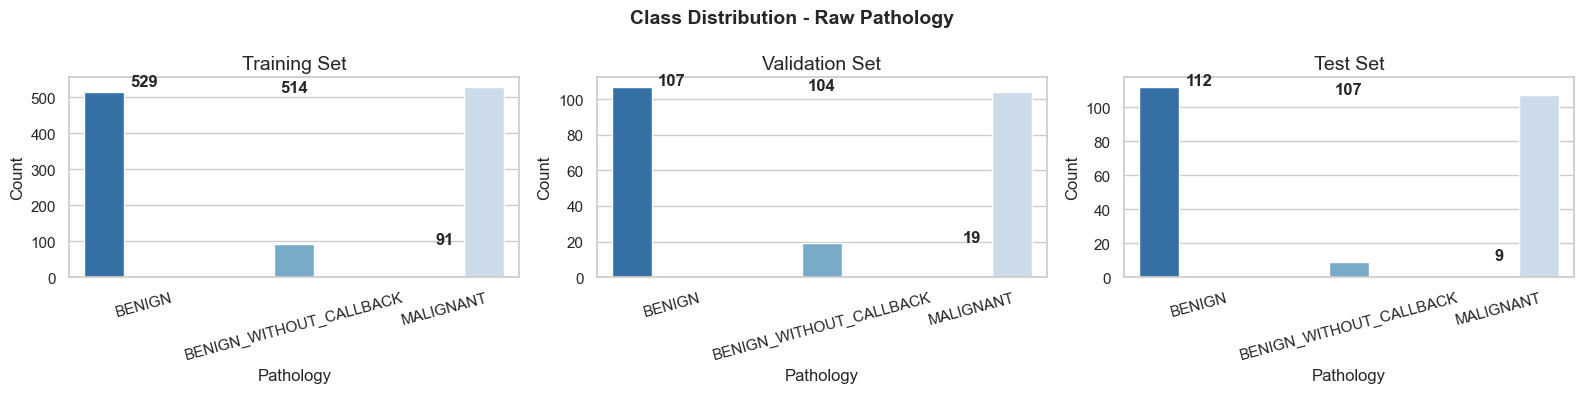

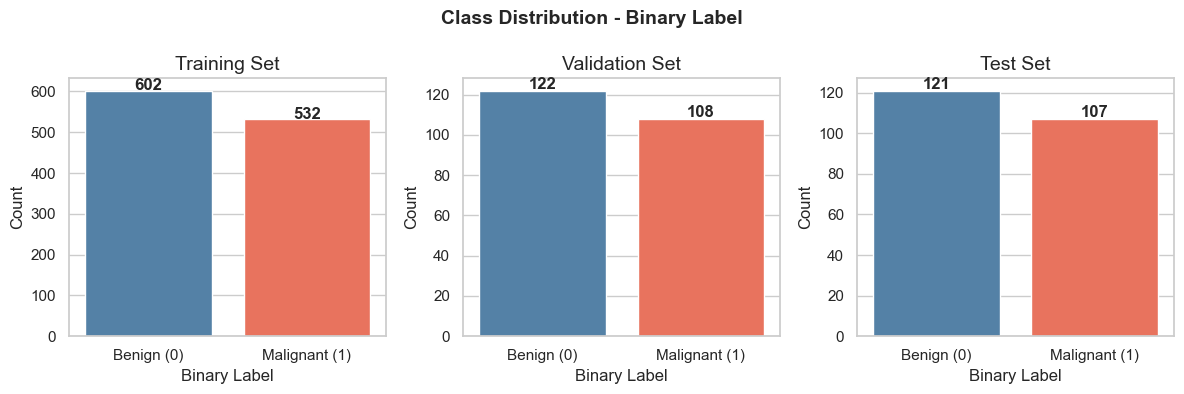


Training label balance:
label
0    0.531
1    0.469
Name: proportion, dtype: float64

Validation label balance:
label
0    0.53
1    0.47
Name: proportion, dtype: float64

Test label balance:
label
0    0.531
1    0.469
Name: proportion, dtype: float64

Patient-level distribution - Train:
  Malignant patients : 307 (48.4%)
  Benign patients    : 327 (51.6%)
  Patient-level ratio: 1.07:1

Patient-level distribution - Val:
  Malignant patients : 62 (48.1%)
  Benign patients    : 67 (51.9%)
  Patient-level ratio: 1.08:1

Patient-level distribution - Test:
  Malignant patients : 62 (48.1%)
  Benign patients    : 67 (51.9%)
  Patient-level ratio: 1.08:1
Class imbalance ratio (benign:malignant): 1.13:1
Naive majority-class accuracy: 53.1%

=== Three-Way Pathology Breakdown (Training Set) ===
  MALIGNANT                    :  529  (46.6%)
  BENIGN                       :  514  (45.3%)
  BENIGN_WITHOUT_CALLBACK      :   91  (8.0%)

BENIGN_WITHOUT_CALLBACK (91 cases) mapped to label 0 (consist

In [8]:
for _df in (train_df, val_df, test_df):
    assert "label" in _df.columns and _df["label"].notna().all()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, df, title in zip(axes, [train_df, val_df, test_df], ["Training Set", "Validation Set", "Test Set"]):
    counts = df["pathology"].value_counts()
    sns.barplot(
        x=counts.index,
        y=counts.values,
        hue=counts.index,
        palette="Blues_r",
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Pathology")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.suptitle("Class Distribution - Raw Pathology", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "class_distribution_raw.png")
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
for ax, df, title in zip(axes2, [train_df, val_df, test_df], ["Training Set", "Validation Set", "Test Set"]):
    counts = df["label"].value_counts().sort_index()
    sns.barplot(
        x=["Benign (0)", "Malignant (1)"],
        y=counts.values,
        hue=["Benign (0)", "Malignant (1)"],
        palette=["steelblue", "tomato"],
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Binary Label")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.suptitle("Class Distribution - Binary Label", fontsize=14, fontweight="bold")
plt.tight_layout()
fig2.savefig(CONFIG["figures_dir"] / "class_distribution_binary.png")
plt.show()

for name, df in [("Training", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{name} label balance:")
    print(df["label"].value_counts(normalize=True).round(3))

# Patient-level distribution; max() labels a patient malignant if any mass is - clinically conservative.
for split_name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    patient_labels = df.groupby("patient_id")["label"].max()
    mal = (patient_labels == 1).sum()
    ben = (patient_labels == 0).sum()
    print(f"\nPatient-level distribution - {split_name}:")
    print(f"  Malignant patients : {mal} ({mal/len(patient_labels):.1%})")
    print(f"  Benign patients    : {ben} ({ben/len(patient_labels):.1%})")
    print(f"  Patient-level ratio: {ben/mal:.2f}:1")

majority_class_acc = train_df["label"].value_counts(normalize=True).max()
imbalance_ratio = (train_df["label"] == 0).sum() / (train_df["label"] == 1).sum()
print(f"Class imbalance ratio (benign:malignant): {imbalance_ratio:.2f}:1")
print(f"Naive majority-class accuracy: {majority_class_acc:.1%}")

# BENIGN_WITHOUT_CALLBACK = no recall required; most confidently benign cases.
print("\n=== Three-Way Pathology Breakdown (Training Set) ===")
for cat in ["MALIGNANT", "BENIGN", "BENIGN_WITHOUT_CALLBACK"]:
    n = (train_df["pathology"] == cat).sum()
    pct = n / len(train_df) * 100
    print(f"  {cat:<28} : {n:4d}  ({pct:.1f}%)")

bwc_n = (train_df["pathology"] == "BENIGN_WITHOUT_CALLBACK").sum()
print(f"\nBENIGN_WITHOUT_CALLBACK ({bwc_n} cases) mapped to label 0 (consistent with Lee et al., 2017; Wang, 2024).")

# Explain the discrepancy between raw pathology counts and authoritative label counts.
_n_mal_label = int(train_df["label"].sum())
_n_mal_raw = int((train_df["pathology"] == "MALIGNANT").sum())
if _n_mal_label != _n_mal_raw:
    print(
        f"\nNote: {_n_mal_label - _n_mal_raw} image(s) are labelled malignant by the "
        f"authoritative label (max across abnormalities) but listed as BENIGN or "
        f"BENIGN_WITHOUT_CALLBACK in the raw pathology column - these are "
        f"multi-abnormality images with mixed findings (see Section 1 label check)."
    )

# CBIS-DDSM is ~70x enriched over real-world screening prevalence (~0.65%, NHS England 2022).
_nhs_prev_pct = 0.65
_cbis_mal_pct = (train_df["label"] == 1).mean() * 100
_enrichment = _cbis_mal_pct / _nhs_prev_pct

print(f"CBIS-DDSM malignancy rate (train): {_cbis_mal_pct:.1f}%  (~{_enrichment:.0f}x enriched vs real-world screening)")

## 5. Clinical Feature Distributions

The CBIS-DDSM records radiologist-assigned descriptors for each mass. Understanding their distributions is important for three reasons:

1. **Mass shape and margins** are the primary radiological features used by clinicians to distinguish benign from malignant masses (American College of Radiology BI-RADS Atlas, 5th ed.). If the CNN learns representations that correlate with these features, this can be verified via Grad-CAM visualisations in later notebooks.

2. **Assessment** records the radiologist's BI-RADS score (ACR, 2013): categories 1-2 indicate benign findings; category 3 indicates probable benignity; categories 4-5 indicate suspicion of malignancy and typically prompt biopsy. The distribution of assessment scores across pathology classes provides a direct measure of radiologist-model agreement potential.

3. **Subtlety** scores indicate case difficulty. Per Lee et al. (2017), subtlety is scored **1 (subtle, hardest to detect) to 5 (obvious, easiest to detect)**. A dataset with high proportions of score 1-2 cases is more clinically realistic, as these represent subtle abnormalities most likely to cause missed diagnoses in screening practice.

Missing values in `mass shape` and `mass margins` (identified in Section 2) are shown explicitly in the distributions below and do not affect the CNN pipeline, as model input is the raw image.

Feature                     χ²         p    df       V   Sig  Interpretation
──────────────────────────────────────────────────────────────────────────────


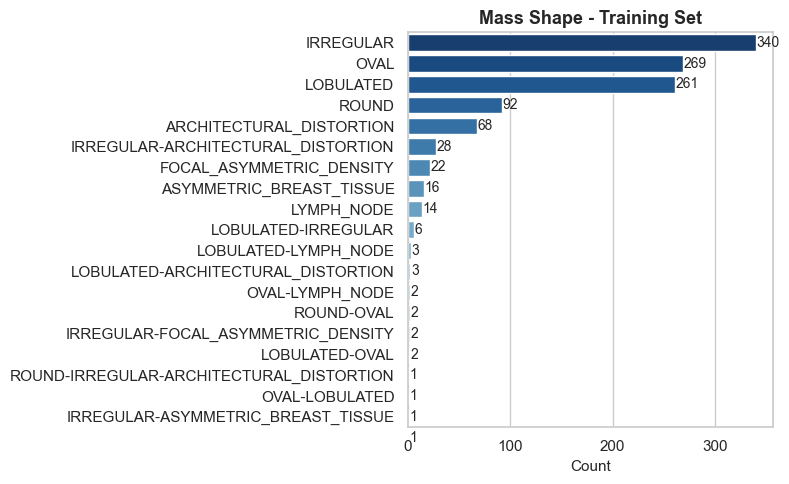

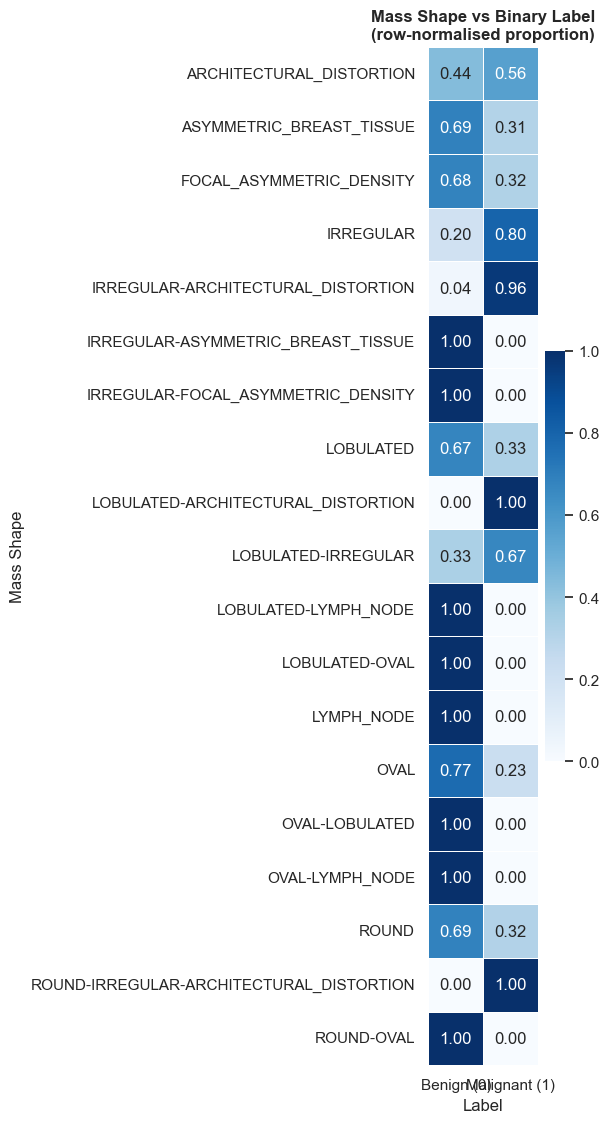

Mass Shape              299.28    0.0000    18   0.514   ***  large effect


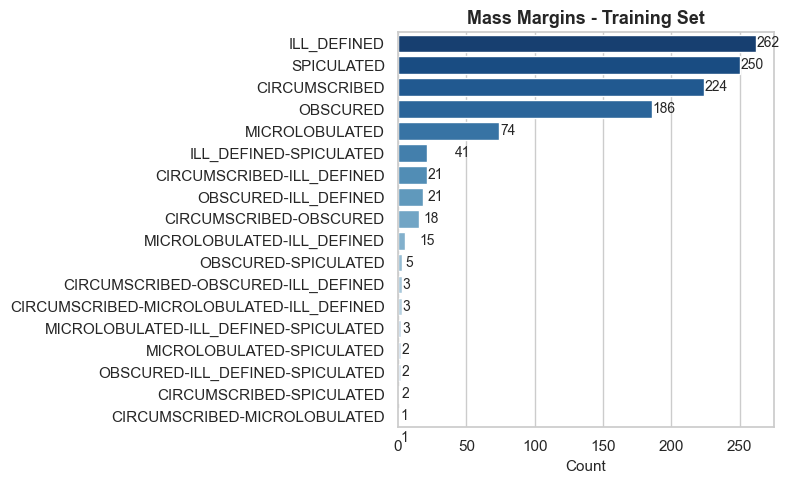

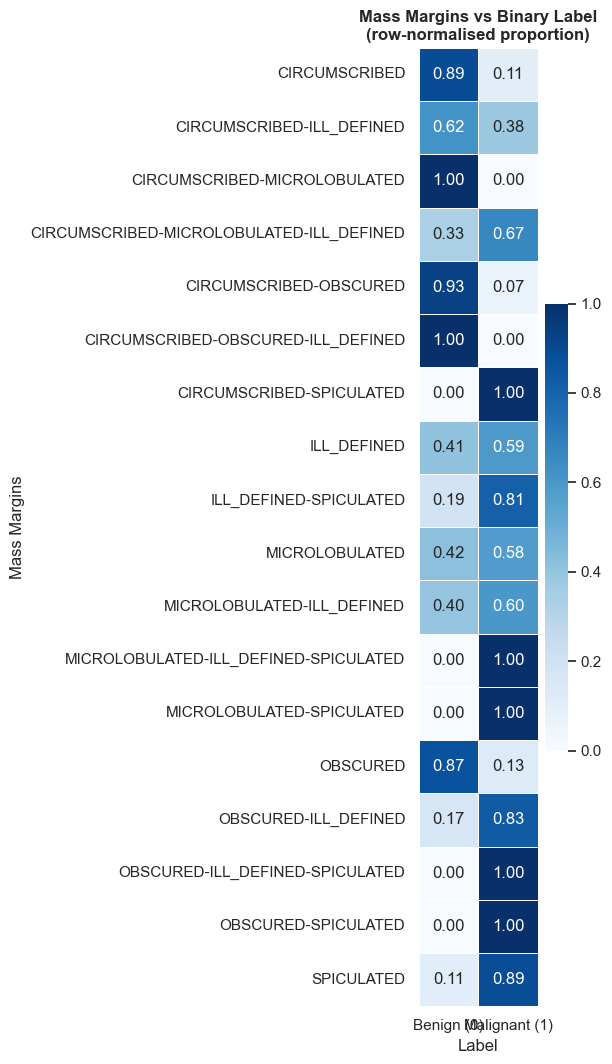

Mass Margins            443.89    0.0000    17   0.637   ***  large effect


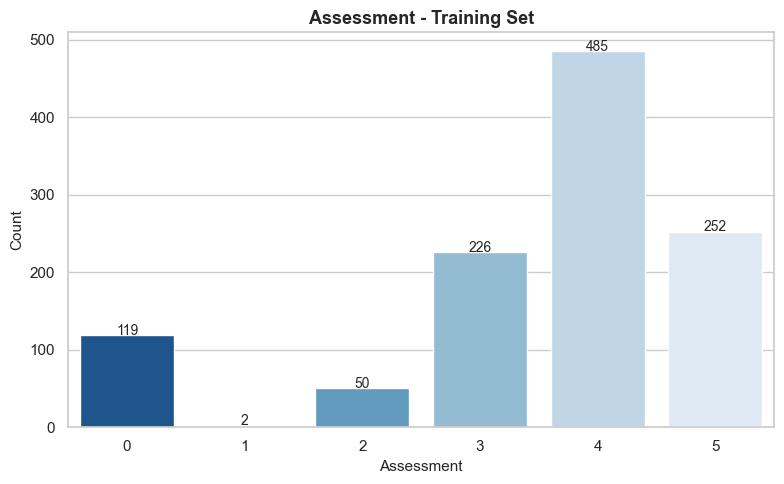

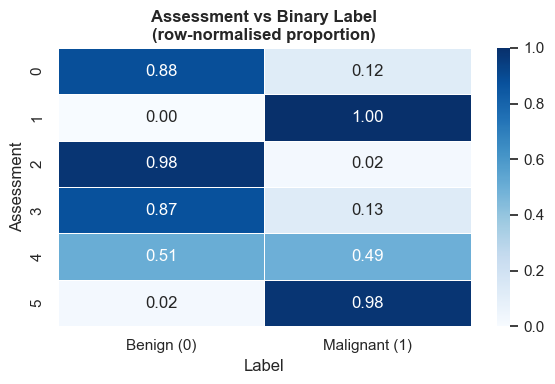

Assessment              472.53    0.0000     5   0.646   ***  large effect


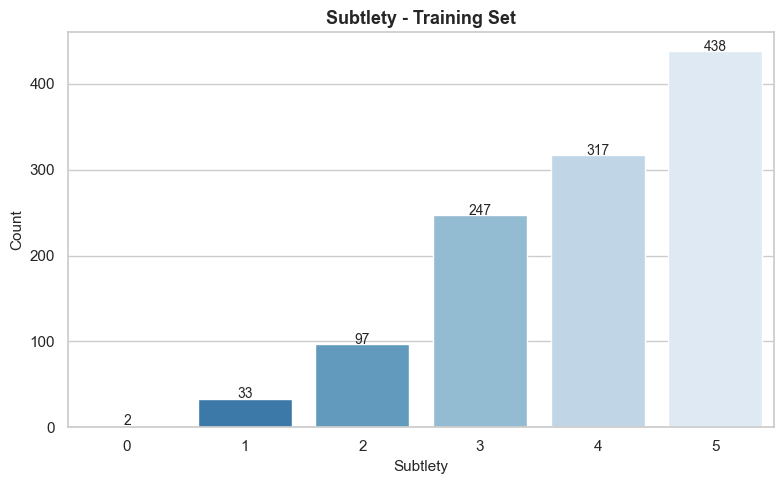

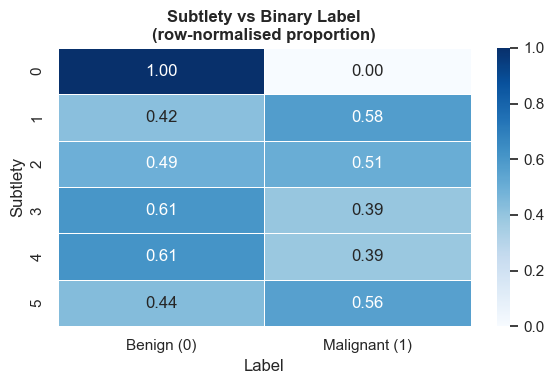

Subtlety                 32.93    0.0000     5   0.170   ***  small effect

Cramér's V: <0.1 = negligible, 0.1-0.3 = small, 0.3-0.5 = medium, >0.5 = large effect
Chi-square significance: * p<0.05, ** p<0.01, *** p<0.001

=== Mann-Whitney U Test (ordinal features: assessment, subtlety) ===

Assessment
  U = 269760,  p = 1.0674e-97,  r_rb = -0.685  ***
  Malignant mean: 4.29  |  Benign mean: 2.82
  -> Malignant cases score higher on assessment

Subtlety
  U = 177464,  p = 9.6007e-04,  r_rb = -0.108  ***
  Malignant mean: 3.99  |  Benign mean: 3.83
  -> Malignant cases score higher on subtlety

=== Train vs Val vs Test Distribution Comparison (proportions) ===

--- Mass Shape ---
                                          Train    Val   Test
mass shape                                                   
ARCHITECTURAL_DISTORTION                  0.060  0.078  0.044
ASYMMETRIC_BREAST_TISSUE                  0.014  0.017  0.022
FOCAL_ASYMMETRIC_DENSITY                  0.019  0.009  0.000
IRRE

In [9]:
present_cols = [c for c in CONFIG["clinical_cols"] if c in train_df.columns]

print(
    f"{'Feature':<20}  {'χ²':>8}  {'p':>8}  {'df':>4}  {'V':>6}  {'Sig':>4}  Interpretation"
)
print("─" * 78)

for col in present_cols:

    # Distribution plot (training set)
    counts = train_df[col].value_counts(dropna=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    if len(counts) > 6:
        sns.barplot(
            x=counts.values,
            y=counts.index.astype(str),
            hue=counts.index.astype(str),
            palette="Blues_r",
            legend=False,
            ax=ax,
        )
        ax.set_xlabel("Count", fontsize=11)
        ax.set_ylabel("")
        for i, v in enumerate(counts.values):
            ax.text(v + 0.5, i, str(v), va="center", fontsize=10)
    else:
        if col in ("assessment", "subtlety"):
            counts = counts.sort_index()
        sns.barplot(
            x=counts.index.astype(str),
            y=counts.values,
            hue=counts.index.astype(str),
            palette="Blues_r",
            legend=False,
            ax=ax,
        )
        ax.set_xlabel(col.title(), fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        for i, v in enumerate(counts.values):
            ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)

    ax.set_title(f"{col.title()} - Training Set", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fig.savefig(
        CONFIG["figures_dir"] / f"clinical_{col.replace(' ', '_')}_distribution.png"
    )
    plt.show()

    # Binary label heatmap (row-normalised)
    ct = pd.crosstab(train_df[col], train_df["label"], normalize="index").round(3)
    ct.columns = ["Benign (0)", "Malignant (1)"]

    fig, ax = plt.subplots(figsize=(6, max(4, len(ct) * 0.6)))
    sns.heatmap(
        ct, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5, ax=ax, vmin=0, vmax=1
    )
    ax.set_title(
        f"{col.title()} vs Binary Label\n(row-normalised proportion)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Label")
    ax.set_ylabel(col.title())
    plt.tight_layout()
    fig.savefig(
        CONFIG["figures_dir"] / f"clinical_{col.replace(' ', '_')}_vs_label.png"
    )
    plt.show()

    # Cramér's V measures association strength - with n=1318, p-values alone are uninformative.
    ct_raw = pd.crosstab(
        train_df[col].dropna(), train_df.loc[train_df[col].notna(), "label"]
    )
    chi2_stat, p_val, dof, _ = chi2_contingency(ct_raw)

    n_ct = ct_raw.values.sum()
    k, r = ct_raw.shape
    v = np.sqrt(chi2_stat / (n_ct * (min(k, r) - 1)))

    sig = (
        "***"
        if p_val < 0.001
        else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
    )
    v_str = "negligible" if v < 0.1 else ("small" if v < 0.3 else ("medium" if v < 0.5 else "large"))
    print(
        f"{col.title():<20}  {chi2_stat:>8.2f}  {p_val:>8.4f}  {dof:>4}  {v:>6.3f}  {sig:>4}  {v_str} effect"
    )

print()
print("Cramér's V: <0.1 = negligible, 0.1-0.3 = small, 0.3-0.5 = medium, >0.5 = large effect")
print("Chi-square significance: * p<0.05, ** p<0.01, *** p<0.001")
print()

# Mann-Whitney U preserves ordinal structure that chi-square discards.
print("=== Mann-Whitney U Test (ordinal features: assessment, subtlety) ===\n")
for col in ["assessment", "subtlety"]:
    if col not in train_df.columns:
        continue
    g0 = train_df[train_df["label"] == 0][col].dropna()
    g1 = train_df[train_df["label"] == 1][col].dropna()
    stat, p = mannwhitneyu(g1, g0, alternative="two-sided")
    n0, n1 = len(g0), len(g1)
    r_rb = 1 - (2 * stat) / (n0 * n1)
    direction = "higher" if g1.mean() > g0.mean() else "lower"
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{col.title()}")
    print(f"  U = {stat:.0f},  p = {p:.4e},  r_rb = {r_rb:+.3f}  {sig}")
    print(f"  Malignant mean: {g1.mean():.2f}  |  Benign mean: {g0.mean():.2f}")
    print(f"  -> Malignant cases score {direction} on {col}")
    print()

# Train vs val vs test distribution comparison
print("=== Train vs Val vs Test Distribution Comparison (proportions) ===\n")
for col in present_cols:
    train_props = train_df[col].value_counts(normalize=True, dropna=False).round(3)
    val_props = val_df[col].value_counts(normalize=True, dropna=False).round(3)
    test_props = test_df[col].value_counts(normalize=True, dropna=False).round(3)
    comparison = pd.DataFrame({"Train": train_props, "Val": val_props, "Test": test_props}).fillna(0)
    print(f"--- {col.title()} ---")
    print(comparison.to_string())
    print()

## 5b. Breast Density

ACR BI-RADS breast density is classified on a four-point scale:
- **Category 1** (almost entirely fatty): High contrast; masses visible against fatty background
- **Category 2** (scattered fibroglandular): Some dense areas; most masses visible
- **Category 3** (heterogeneously dense): Moderate masking; some masses may be hidden
- **Category 4** (extremely dense): Severe masking; mammographic sensitivity significantly reduced

Dense breast tissue (categories 3-4) attenuates X-rays in a similar way to soft-tissue lesions, reducing the contrast that distinguishes masses from background parenchyma. Mammographic sensitivity falls from ~90% in fatty breasts to ~60-70% in extremely dense breasts (Kolb et al., 2002). This is the central challenge that motivates AI-assisted reading: a CNN may detect visual patterns in dense tissue that radiologists miss (McKinney et al., 2020; Wang, 2024).

**Case-selection enrichment artefact**: In real-world screening populations, breast density is associated with both higher cancer incidence and lower mammographic sensitivity. However, CBIS-DDSM is curated from cases that were *already recalled for assessment* - meaning every patient had a finding suspicious enough to warrant closer examination. This case-selection process breaks the real-world density->prevalence link: among recalled patients, malignancy probability depends on the nature of the finding, not the background tissue density. The near-flat malignancy rate across density categories seen below (D1: 47.3%, D2: 50.0%, D3: 43.3%, D4: 42.6%) is therefore expected and does not contradict the clinical literature - it reflects dataset enrichment, not biology.

**Train vs val vs test density distribution**: proportions are broadly stable across partitions (D1: 18.1%/19.6%/17.5%; D2: 44.1%/45.2%/49.1%; D3: 28.3%/23.0%/26.8%; D4: 9.5%/12.2%/6.6% for train/val/test). The largest gap is D4's test-set dip; still worth tracking in Phase 9's density-stratified evaluation.

The distribution of density categories and their statistical association with malignancy probability (after conditioning on recall) are characterised below.

**Phase 9 evaluation note**: sensitivity should be stratified by breast density to test whether the trained CNN degrades in dense tissue as human readers do.

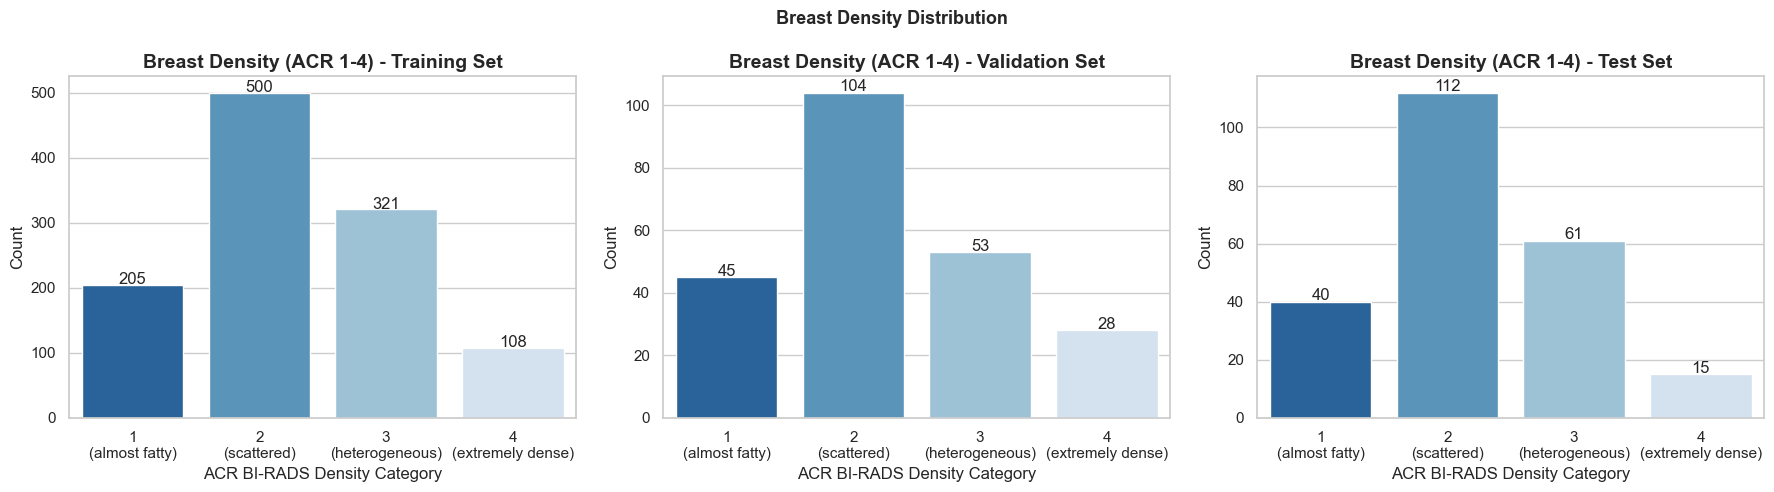

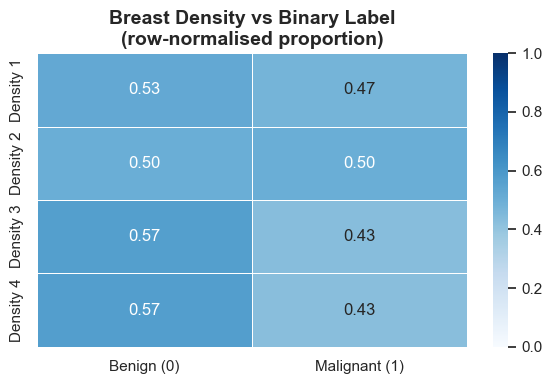

=== Breast Density Association with Malignancy ===

Chi-square  : χ²=4.42,  p=0.2199,  df=3
Cramér's V  : 0.062  (negligible effect)  ns
Mann-Whitney: U=152165,  p=0.1239,  r_rb=+0.050  ns

Malignancy rate per density category (training set):
  Density 1: 47.3% malignant  (n= 205)  ██████████████
  Density 2: 50.0% malignant  (n= 500)  ███████████████
  Density 3: 43.3% malignant  (n= 321)  ████████████
  Density 4: 42.6% malignant  (n= 108)  ████████████

=== Breast Density - Train vs Val vs Test Comparison ===
                Train    Val   Test
breast_density                     
1               0.181  0.196  0.175
2               0.441  0.452  0.491
3               0.283  0.230  0.268
4               0.095  0.122  0.066


In [10]:
_density_labels = {
    1: "1\n(almost fatty)",
    2: "2\n(scattered)",
    3: "3\n(heterogeneous)",
    4: "4\n(extremely dense)",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, df, title in zip(axes, [train_df, val_df, test_df], ["Training Set", "Validation Set", "Test Set"]):
    counts = df["breast_density"].value_counts().sort_index()
    x_labels = [_density_labels.get(int(i), str(i)) for i in counts.index]
    sns.barplot(
        x=x_labels,
        y=counts.values,
        hue=x_labels,
        palette="Blues_r",
        legend=False,
        ax=ax,
    )
    ax.set_title(f"Breast Density (ACR 1-4) - {title}", fontweight="bold")
    ax.set_xlabel("ACR BI-RADS Density Category")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha="center")

plt.suptitle("Breast Density Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "breast_density_distribution.png")
plt.show()

ct_bd = pd.crosstab(
    train_df["breast_density"], train_df["label"], normalize="index"
).round(3)
ct_bd.columns = ["Benign (0)", "Malignant (1)"]
ct_bd.index = [f"Density {int(i)}" for i in ct_bd.index]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    ct_bd, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_title(
    "Breast Density vs Binary Label\n(row-normalised proportion)", fontweight="bold"
)
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "breast_density_vs_label.png")
plt.show()

ct_bd_raw = pd.crosstab(train_df["breast_density"], train_df["label"])
chi2_bd, p_bd, dof_bd, _ = chi2_contingency(ct_bd_raw)
n_bd = ct_bd_raw.values.sum()
k_bd, r_bd = ct_bd_raw.shape
v_bd = np.sqrt(chi2_bd / (n_bd * (min(k_bd, r_bd) - 1)))

print("=== Breast Density Association with Malignancy ===\n")
print(f"Chi-square  : χ²={chi2_bd:.2f},  p={p_bd:.4f},  df={dof_bd}")
sig_bd = (
    "***" if p_bd < 0.001 else ("**" if p_bd < 0.01 else ("*" if p_bd < 0.05 else "ns"))
)
v_bd_str = "negligible" if v_bd < 0.1 else ("small" if v_bd < 0.3 else ("medium" if v_bd < 0.5 else "large"))
print(f"Cramér's V  : {v_bd:.3f}  ({v_bd_str} effect)  {sig_bd}")

# Mann-Whitney U (density is ordinal: 1 < 2 < 3 < 4)
g0_bd = train_df[train_df["label"] == 0]["breast_density"]
g1_bd = train_df[train_df["label"] == 1]["breast_density"]
stat_bd, p_mw_bd = mannwhitneyu(g1_bd, g0_bd, alternative="two-sided")
n0_bd, n1_bd = len(g0_bd), len(g1_bd)
r_rb_bd = 1 - (2 * stat_bd) / (n0_bd * n1_bd)
sig_mw_bd = (
    "***"
    if p_mw_bd < 0.001
    else ("**" if p_mw_bd < 0.01 else ("*" if p_mw_bd < 0.05 else "ns"))
)

print(
    f"Mann-Whitney: U={stat_bd:.0f},  p={p_mw_bd:.4f},  r_rb={r_rb_bd:+.3f}  {sig_mw_bd}"
)
print()

print("Malignancy rate per density category (training set):")
_dens_stats = (
    train_df.groupby("breast_density")["label"].agg(["mean", "count"]).reset_index()
)
_dens_stats.columns = ["density", "malignant_rate", "count"]

for _, row in _dens_stats.iterrows():
    bar = "█" * int(row["malignant_rate"] * 30)
    d_lbl = _density_labels.get(int(row["density"]), str(int(row["density"])))
    print(
        f"  Density {int(row['density'])}: {row['malignant_rate']:.1%} malignant  "
        f"(n={int(row['count']):4d})  {bar}"
    )

print("\n=== Breast Density - Train vs Val vs Test Comparison ===")
_bd_comp = pd.DataFrame(
    {
        "Train": train_df["breast_density"].value_counts(normalize=True).sort_index().round(3),
        "Val": val_df["breast_density"].value_counts(normalize=True).sort_index().round(3),
        "Test": test_df["breast_density"].value_counts(normalize=True).sort_index().round(3),
    }
)
print(_bd_comp.to_string())

## 5c. BI-RADS Clinical Baseline and Radiologist-Pathology Discordance

Before building any CNN, establishing the performance achievable from clinical features alone sets the minimum bar the model must exceed to be useful.

**BI-RADS assessment** (`assessment` column, scores 0-5) is the radiologist's summary judgement. In clinical practice, BI-RADS ≥ 4 triggers biopsy referral (ACR BI-RADS Atlas, 5th ed., 2013). Applying this same threshold here gives the sensitivity and specificity that the radiologist's scoring system achieves on this dataset.

Using the BI-RADS score as a *continuous* predictor and computing its AUC-ROC gives a second, threshold-free baseline. **Any CNN claiming clinical utility must exceed both**. The binding CNN training targets derived from this dataset are:

> **AUC-ROC > 0.813** - the BI-RADS continuous-score baseline (test set, n=228)  
> **AUC-PR > 0.745** - the BI-RADS precision-recall baseline (test set, n=228)  
> **Sensitivity > 0.897** - the BI-RADS ≥ 4 threshold baseline (96/107 true cancers detected; test set)

A model that does not exceed these values adds no discriminative value beyond the radiologist's existing BI-RADS assessment.

**BI-RADS 1 scoring anomaly**: Two views of patient P_00641 (train) and one view of patient P_00607 (val) have assessment = 1 (definitively negative) but pathology = MALIGNANT. BI-RADS 1 in clinical practice means no abnormality detected; a malignant outcome is therefore inconsistent with the score. Almost certainly a data-entry error in the source CBIS-DDSM CSV, affecting two patients across two partitions. Retained for completeness.

**Discordant cases** - where the BI-RADS score and the pathology-confirmed label disagree - are the most clinically significant cases in the dataset:
- *False alarms* (BI-RADS ≥ 4, pathology BENIGN): unnecessary biopsy referral
- *Missed cancers* (BI-RADS ≤ 2, pathology MALIGNANT): the highest-value cases for AI

If the CNN can correctly classify missed cancers, it adds genuine clinical value beyond what the radiologist's feature-level assessment captures.

**A note on where these cases land**: the split is patient-level and stratified on the binary malignant/benign label only - it does not control the much rarer *nested* event of a missed cancer (BI-RADS ≤ 2 *and* malignant), which affects only ~1.5-3.9% of malignant cases. Which partition that nested event lands in is therefore largely down to chance for a single split. Here it lands entirely in train and val (17 and 9 cases) and not at all in test - a property of this split, not evidence that missed cancers are absent from the dataset. Phase 8/9 case-level inspection should draw on train/val for missed-cancer examples, not test.

BI-RADS baseline computed on 228 test images


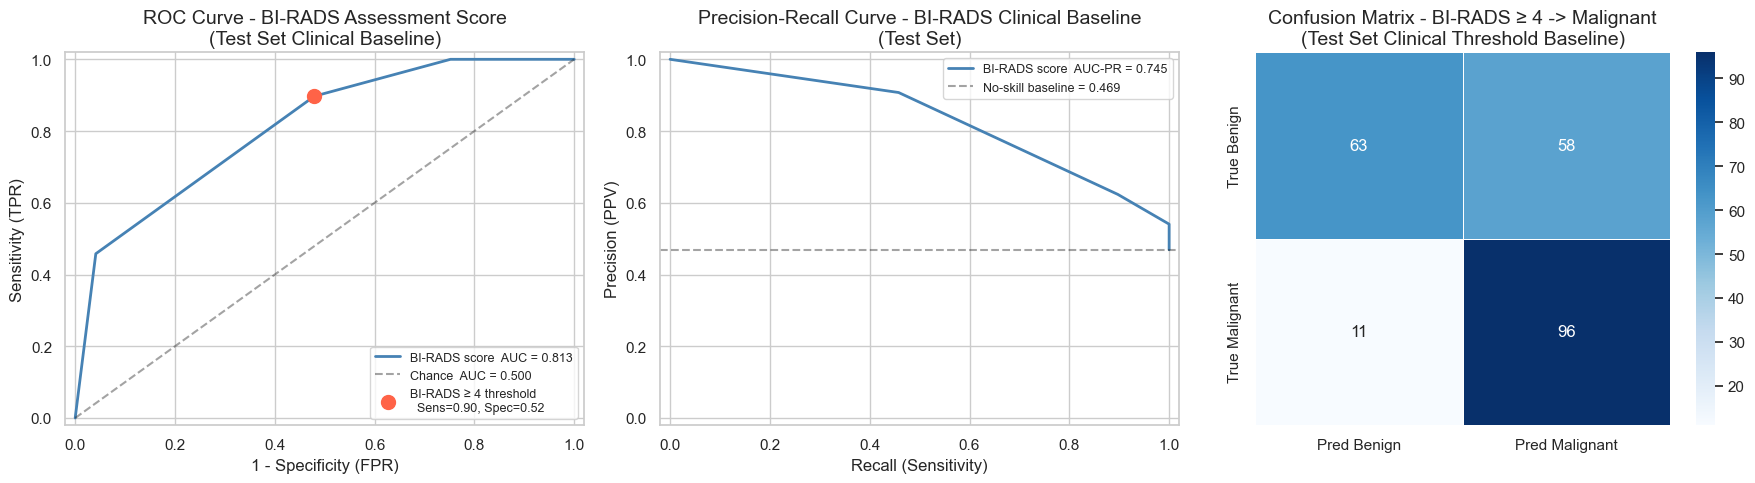

=== BI-RADS Clinical Baseline - TEST SET (BI-RADS ≥ 4 -> predict malignant) ===
  Sensitivity (Recall): 0.897  - 96/107 true cancers detected
  Specificity: 0.521  - 63/121 true benigns correctly excluded
  PPV (Precision): 0.623
  NPV: 0.851
  Accuracy: 0.697

=== BI-RADS Score as Continuous Predictor - TEST SET ===
  AUC-ROC (assessment): 0.813
  AUC-PR  (assessment): 0.745

Binding CNN training targets (must exceed on the test set):
  AUC-ROC > 0.813  (exceed BI-RADS discrimination)
  AUC-PR  > 0.745  (exceed BI-RADS precision-recall)
  Sensitivity > 0.897  (exceed BI-RADS threshold recall)

=== Radiologist-Pathology Discordance (Test Set) ===

False alarms  (BI-RADS ≥ 4, pathology BENIGN)     :  58 cases  (25.4%)

Missed cancers (BI-RADS ≤ 2, pathology MALIGNANT) :   0 cases  (0.0%)
✓  config.BIRADS baselines match computed values


In [11]:
# Defensive no-op - test_df should already be unique per image (Section 1).
_df_bi = (
    test_df.sort_values("label", ascending=False)
    .drop_duplicates(subset=["image file path"])
    .dropna(subset=["assessment"])
    .copy()
)
print(f"BI-RADS baseline computed on {len(_df_bi)} test images")
_y_true = _df_bi["label"].values
_y_score = _df_bi["assessment"].values  # continuous BI-RADS score (0-5)

_auc_bi = roc_auc_score(_y_true, _y_score)
_fpr, _tpr, _thresholds = roc_curve(_y_true, _y_score)

_auc_pr_bi = average_precision_score(_y_true, _y_score)
_precision, _recall, _ = precision_recall_curve(_y_true, _y_score)

_y_pred = (_y_score >= 4).astype(int)
_cm = confusion_matrix(_y_true, _y_pred)
_tn, _fp, _fn, _tp = _cm.ravel()

_sensitivity = _tp / (_tp + _fn)
_specificity = _tn / (_tn + _fp)
_ppv = _tp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
_npv = _tn / (_tn + _fn) if (_tn + _fn) > 0 else 0.0
_accuracy = (_tp + _tn) / len(_y_true)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
axes[0].plot(
    _fpr, _tpr, color="steelblue", lw=2, label=f"BI-RADS score  AUC = {_auc_bi:.3f}"
)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance  AUC = 0.500")
_op_idx = np.argmin(np.abs(_thresholds - 4))
axes[0].scatter(
    _fpr[_op_idx],
    _tpr[_op_idx],
    color="tomato",
    s=100,
    zorder=5,
    label=f"BI-RADS ≥ 4 threshold\n  Sens={_sensitivity:.2f}, Spec={_specificity:.2f}",
)
axes[0].set_xlabel("1 - Specificity (FPR)")
axes[0].set_ylabel("Sensitivity (TPR)")
axes[0].set_title("ROC Curve - BI-RADS Assessment Score\n(Test Set Clinical Baseline)")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)

# PR curve
_no_skill = (_y_true == 1).mean()
axes[1].plot(
    _recall,
    _precision,
    color="steelblue",
    lw=2,
    label=f"BI-RADS score  AUC-PR = {_auc_pr_bi:.3f}",
)
axes[1].axhline(
    _no_skill,
    color="k",
    linestyle="--",
    alpha=0.4,
    label=f"No-skill baseline = {_no_skill:.3f}",
)
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision (PPV)")
axes[1].set_title("Precision-Recall Curve - BI-RADS Clinical Baseline\n(Test Set)")
axes[1].legend(fontsize=9)
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)

# Confusion matrix
sns.heatmap(
    _cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    xticklabels=["Pred Benign", "Pred Malignant"],
    yticklabels=["True Benign", "True Malignant"],
    ax=axes[2],
)
axes[2].set_title(
    "Confusion Matrix - BI-RADS ≥ 4 -> Malignant\n(Test Set Clinical Threshold Baseline)"
)

plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "birads_clinical_baseline.png")
plt.show()

print("=== BI-RADS Clinical Baseline - TEST SET (BI-RADS ≥ 4 -> predict malignant) ===")
print(
    f"  Sensitivity (Recall): {_sensitivity:.3f}  - {_tp}/{_tp+_fn} true cancers detected"
)
print(
    f"  Specificity: {_specificity:.3f}  - {_tn}/{_tn+_fp} true benigns correctly excluded"
)
print(f"  PPV (Precision): {_ppv:.3f}")
print(f"  NPV: {_npv:.3f}")
print(f"  Accuracy: {_accuracy:.3f}")
print(f"\n=== BI-RADS Score as Continuous Predictor - TEST SET ===")
print(f"  AUC-ROC (assessment): {_auc_bi:.3f}")
print(f"  AUC-PR  (assessment): {_auc_pr_bi:.3f}")
print(f"\nBinding CNN training targets (must exceed on the test set):")
print(f"  AUC-ROC > {_auc_bi:.3f}  (exceed BI-RADS discrimination)")
print(f"  AUC-PR  > {_auc_pr_bi:.3f}  (exceed BI-RADS precision-recall)")
print(f"  Sensitivity > {_sensitivity:.3f}  (exceed BI-RADS threshold recall)")

_false_alarms = _df_bi[(_df_bi["assessment"] >= 4) & (_df_bi["label"] == 0)]
_missed = _df_bi[(_df_bi["assessment"] <= 2) & (_df_bi["label"] == 1)]

print(f"\n=== Radiologist-Pathology Discordance (Test Set) ===")
print(
    f"\nFalse alarms  (BI-RADS ≥ 4, pathology BENIGN)     : "
    f"{len(_false_alarms):3d} cases  ({len(_false_alarms)/len(_df_bi):.1%})"
)
print(
    f"\nMissed cancers (BI-RADS ≤ 2, pathology MALIGNANT) : "
    f"{len(_missed):3d} cases  ({len(_missed)/len(_df_bi):.1%})"
)

if not _missed.empty:
    _cols_show = [
        c
        for c in [
            "patient_id",
            "assessment",
            "pathology",
            "mass shape",
            "mass margins",
            "subtlety",
        ]
        if c in _missed.columns
    ]
    display(_missed[_cols_show].head(10))

_detected_mal = _df_bi[(_df_bi["assessment"] >= 4) & (_df_bi["label"] == 1)]
if "subtlety" in _df_bi.columns and not _missed.empty:
    print(f"\nSubtlety - missed malignancies  : mean={_missed['subtlety'].mean():.2f}")
    print(
        f"Subtlety - detected malignancies: mean={_detected_mal['subtlety'].mean():.2f}"
    )

# Verify config.py baselines match the values just computed.
assert abs(config.BIRADS_AUC_BASELINE - _auc_bi) < 1e-3, (
    f"config.py AUC {config.BIRADS_AUC_BASELINE} != computed {_auc_bi:.3f}"
)
assert abs(config.BIRADS_SENSITIVITY_BASELINE - _sensitivity) < 1e-3, (
    f"config.py sensitivity {config.BIRADS_SENSITIVITY_BASELINE} != computed {_sensitivity:.3f}"
)
assert abs(config.BIRADS_AUCPR_BASELINE - _auc_pr_bi) < 1e-3, (
    f"config.py AUC-PR {config.BIRADS_AUCPR_BASELINE} != computed {_auc_pr_bi:.3f}"
)
print("✓  config.BIRADS baselines match computed values")

In [12]:
print("=== Missed-Cancer Discordance - All Partitions ===")
for _name, _df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    _d = _df.dropna(subset=["assessment"])
    _miss = _d[(_d["assessment"] <= 2) & (_d["label"] == 1)]
    _det = _d[(_d["assessment"] >= 4) & (_d["label"] == 1)]
    line = f"{_name}: {len(_miss)} / {len(_d)} missed-cancer cases ({len(_miss)/len(_d):.1%})"
    if not _miss.empty and "subtlety" in _miss.columns:
        line += f"  | mean subtlety - missed: {_miss['subtlety'].mean():.2f}  detected: {_det['subtlety'].mean():.2f}"
    print(line)

=== Missed-Cancer Discordance - All Partitions ===
Train: 17 / 1134 missed-cancer cases (1.5%)  | mean subtlety - missed: 3.82  detected: 4.06
Val: 9 / 230 missed-cancer cases (3.9%)  | mean subtlety - missed: 3.67  detected: 3.89
Test: 0 / 228 missed-cancer cases (0.0%)


**Findings across train/val**: missed-cancer subtlety (3.82 train, 3.67 val) sits
closer to the dataset's mid-to-high range than to the "hard to see" end - tempering
the assumption that BI-RADS misses are driven mainly by visual subtlety. Val's higher
rate than train's (3.9% vs 1.5%) is itself a small demonstration of how volatile this
nested event is across partitions. These look more like clinical-judgement
discordances than visibility failures - worth keeping in mind for Phase 8 Grad-CAM
inspection of these specific cases, since "subtle" and "diagnostically difficult"
aren't the same thing here.

## 6. View Coverage - CC and MLO Availability per Patient

In standard mammography protocol, each breast is imaged in both the craniocaudal (CC) and mediolateral oblique (MLO) projections. Patients for whom only one view is available have reduced diagnostic coverage and may be harder cases for both radiologists and CNNs. Documenting view availability informs whether single-view or multi-view strategies are feasible for this dataset (Wang, 2024).

**View coverage finding**: **~70.8%/70.4%/71.4%** of patient-breast units in train/val/test (470/664, 95/135, 95/133) have both CC and MLO images recorded. Coverage is consistent across all three partitions. This means the Phase 7 dual-stream CC+MLO architecture (Shen et al., 2019) applies to the paired subset only. The remaining ~29.5% of cases with a single recorded view require either a separate single-view branch or exclusion from the dual-stream model. This is a significant dataset constraint that must be acknowledged in the final report.


=== Training Set ===
Both CC and MLO: 470
CC only: 63
MLO only: 131
Total patient-breast units: 664
Total patients: 634

=== Validation Set ===
Both CC and MLO: 95
CC only: 10
MLO only: 30
Total patient-breast units: 135
Total patients: 129

=== Test Set ===
Both CC and MLO: 95
CC only: 10
MLO only: 28
Total patient-breast units: 133
Total patients: 129


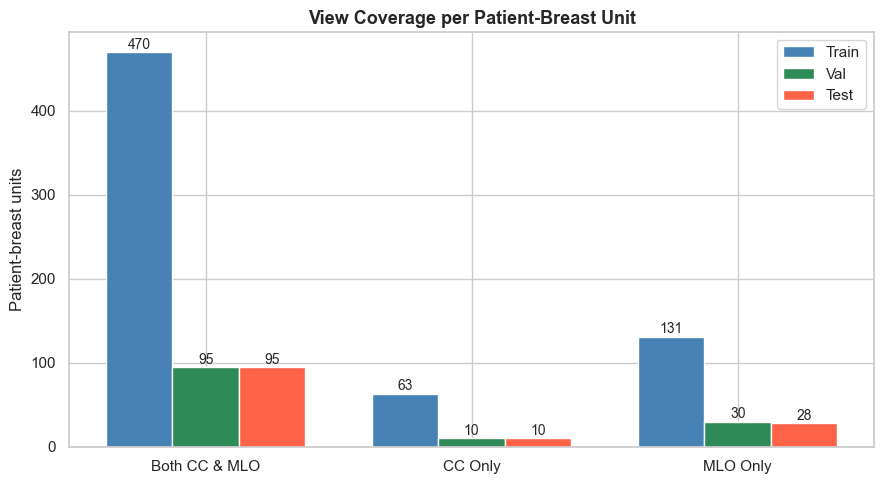


=== Multi-View Pairing - Training Set ===
Patient-breast units total: 664
Complete CC+MLO pairs: 470  (70.8%)
Unpaired (missing CC or MLO): 194
Label distribution (pairs): malignant=223, benign=247  (47.4% malignant)

=== Multi-View Pairing - Validation Set ===
Patient-breast units total: 135
Complete CC+MLO pairs: 95  (70.4%)
Unpaired (missing CC or MLO): 40
Label distribution (pairs): malignant=45, benign=50  (47.4% malignant)

=== Multi-View Pairing - Test Set ===
Patient-breast units total: 133
Complete CC+MLO pairs: 95  (71.4%)
Unpaired (missing CC or MLO): 38
Label distribution (pairs): malignant=45, benign=50  (47.4% malignant)

Paired DataFrame columns: ['patient_id', 'breast', 'CC', 'MLO', 'label']

Sample (first 3 rows):


,patient_id,breast,CC,MLO,label
0,P_00001,LEFT,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,1
1,P_00004,LEFT,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,0
3,P_00009,RIGHT,Mass-Training_P_00009_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00009_RIGHT_MLO/1.3.6.1.4.1.95...,1


In [13]:
def view_coverage(df: pd.DataFrame, name: str) -> dict:
    """Summarise CC/MLO view availability per patient-breast unit.
    
    Measures views with recorded mass annotations, not views taken - a patient
    with a mass visible on CC only will appear CC-only even if MLO exists.
    """
    valid_views = set(CONFIG["valid_views"])
    unexpected = set(df["image view"].dropna().astype(str)) - valid_views
    if unexpected:
        print(f"WARNING [{name}]: unexpected view values: {unexpected}")

    views = df.groupby(["patient_id", "left or right breast"])["image view"].agg(
        frozenset
    )

    both = views.apply(lambda x: "CC" in x and "MLO" in x).sum()
    cc_only = views.apply(lambda x: "CC" in x and "MLO" not in x).sum()
    mlo_only = views.apply(lambda x: "MLO" in x and "CC" not in x).sum()

    print(f"\n=== {name} ===")
    print(f"Both CC and MLO: {both}")
    print(f"CC only: {cc_only}")
    print(f"MLO only: {mlo_only}")
    print(f"Total patient-breast units: {len(views)}")
    print(f"Total patients: {df['patient_id'].dropna().nunique()}")

    return {
        "both": both,
        "cc_only": cc_only,
        "mlo_only": mlo_only,
        "total_units": len(views),
    }


train_coverage = view_coverage(train_df, "Training Set")
val_coverage = view_coverage(val_df, "Validation Set")
test_coverage = view_coverage(test_df, "Test Set")

labels = ["Both CC & MLO", "CC Only", "MLO Only"]
x = np.arange(len(labels))
width = 0.25
train_vals = [train_coverage["both"], train_coverage["cc_only"], train_coverage["mlo_only"]]
val_vals = [val_coverage["both"], val_coverage["cc_only"], val_coverage["mlo_only"]]
test_vals = [test_coverage["both"], test_coverage["cc_only"], test_coverage["mlo_only"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars_train = ax.bar(x - width, train_vals, width, label="Train", color="steelblue")
bars_val = ax.bar(x, val_vals, width, label="Val", color="seagreen")
bars_test = ax.bar(x + width, test_vals, width, label="Test", color="tomato")

ax.set_title("View Coverage per Patient-Breast Unit", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Patient-breast units")
ax.legend()

for bar in list(bars_train) + list(bars_val) + list(bars_test):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "view_coverage.png")
plt.show()

def build_view_pairs(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Pivot to one row per patient-breast unit with CC and MLO path columns.
    Only complete pairs are returned; label = max across the unit (malignant wins).
    """
    df = df.copy()
    df["image view"] = df["image view"].astype(str)

    # Aggregate: one representative image path per (patient, breast, view)
    # First deduplicate within view to handle multi-abnormality images
    agg = (
        df.groupby(["patient_id", "left or right breast", "image view"])
        .agg(img_path=("image file path", "first"), label=("label", "max"))
        .reset_index()
    )

    # Pivot views to columns
    pivot = agg.pivot_table(
        index=["patient_id", "left or right breast"],
        columns="image view",
        values="img_path",
        aggfunc="first",
    ).reset_index()
    pivot.columns.name = None

    # Add patient-breast label (malignant if any view is malignant)
    label_agg = (
        df.groupby(["patient_id", "left or right breast"])["label"].max().reset_index()
    )
    pivot = pivot.merge(
        label_agg, on=["patient_id", "left or right breast"], how="left"
    )

    # Keep only complete CC+MLO pairs
    has_cc = "CC" in pivot.columns
    has_mlo = "MLO" in pivot.columns
    if not (has_cc and has_mlo):
        print(f"WARNING [{name}]: CC or MLO column missing - check view values")
        return pivot

    paired = pivot.dropna(subset=["CC", "MLO"]).copy()
    paired = paired.rename(columns={"left or right breast": "breast"})

    n_total = len(pivot)
    n_paired = len(paired)
    print(f"\n=== Multi-View Pairing - {name} ===")
    print(f"Patient-breast units total: {n_total}")
    print(f"Complete CC+MLO pairs: {n_paired}  ({n_paired/n_total:.1%})")
    print(f"Unpaired (missing CC or MLO): {n_total - n_paired}")
    if "label" in paired.columns:
        mal = paired["label"].sum()
        ben = (paired["label"] == 0).sum()
        print(
            f"Label distribution (pairs): malignant={mal}, benign={ben}  "
            f"({mal/n_paired:.1%} malignant)"
        )

    return paired


train_pairs = build_view_pairs(train_df, "Training Set")
val_pairs = build_view_pairs(val_df, "Validation Set")
test_pairs = build_view_pairs(test_df, "Test Set")

print("\nPaired DataFrame columns:", train_pairs.columns.tolist())
print(f"\nSample (first 3 rows):")
display(train_pairs[["patient_id", "breast", "CC", "MLO", "label"]].head(3))

## 7. Sample Images by Pathology Class

Visual inspection with pathology labels confirms that the DICOM files are loading correctly and gives an intuition for the visual differences between classes that the CNN will need to learn.

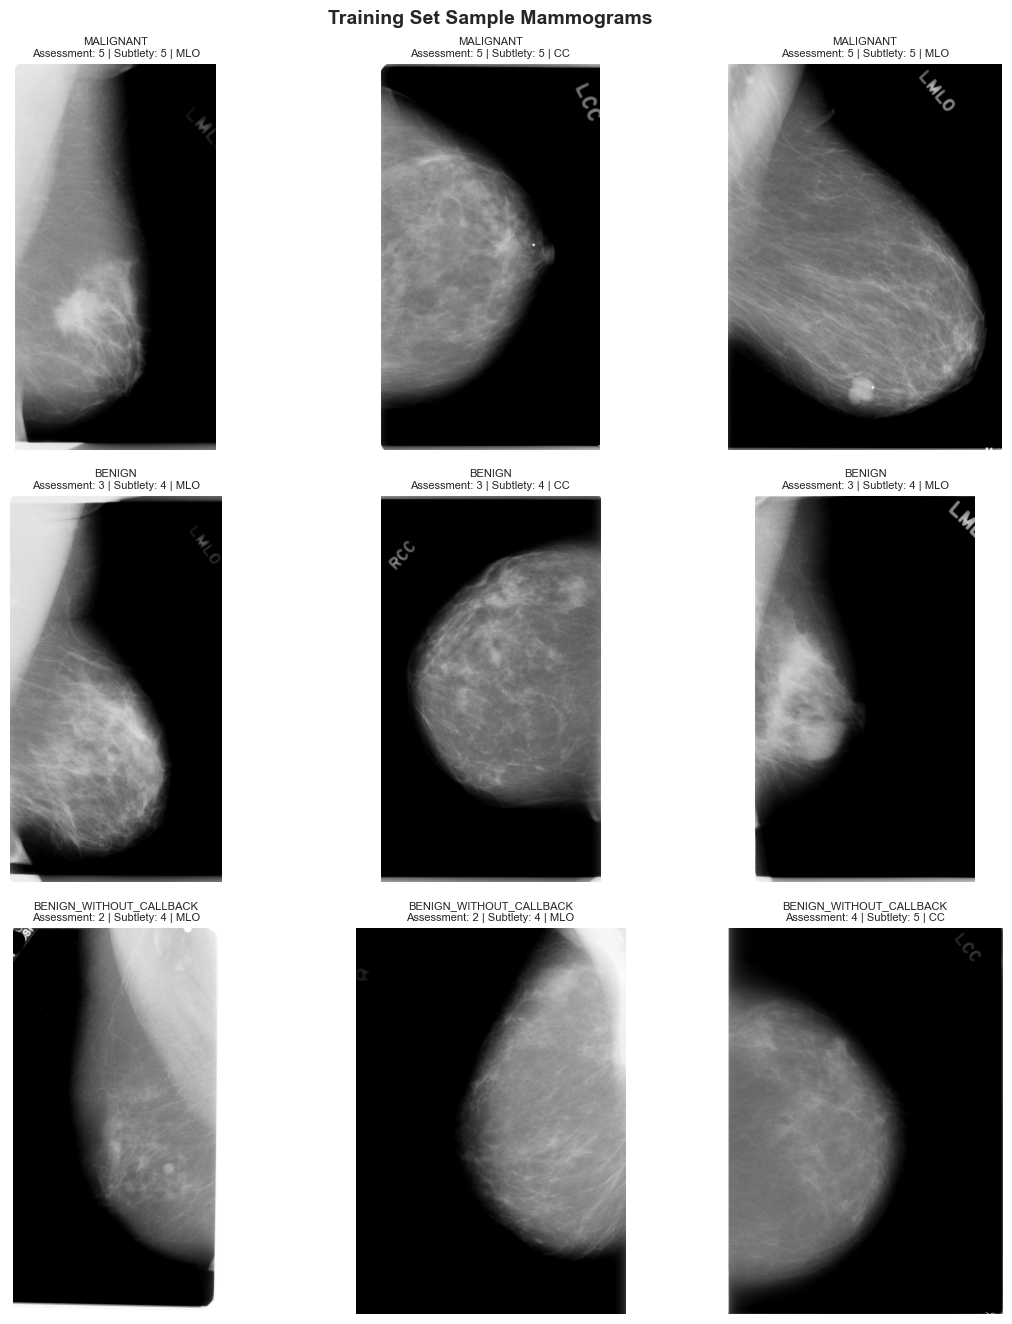

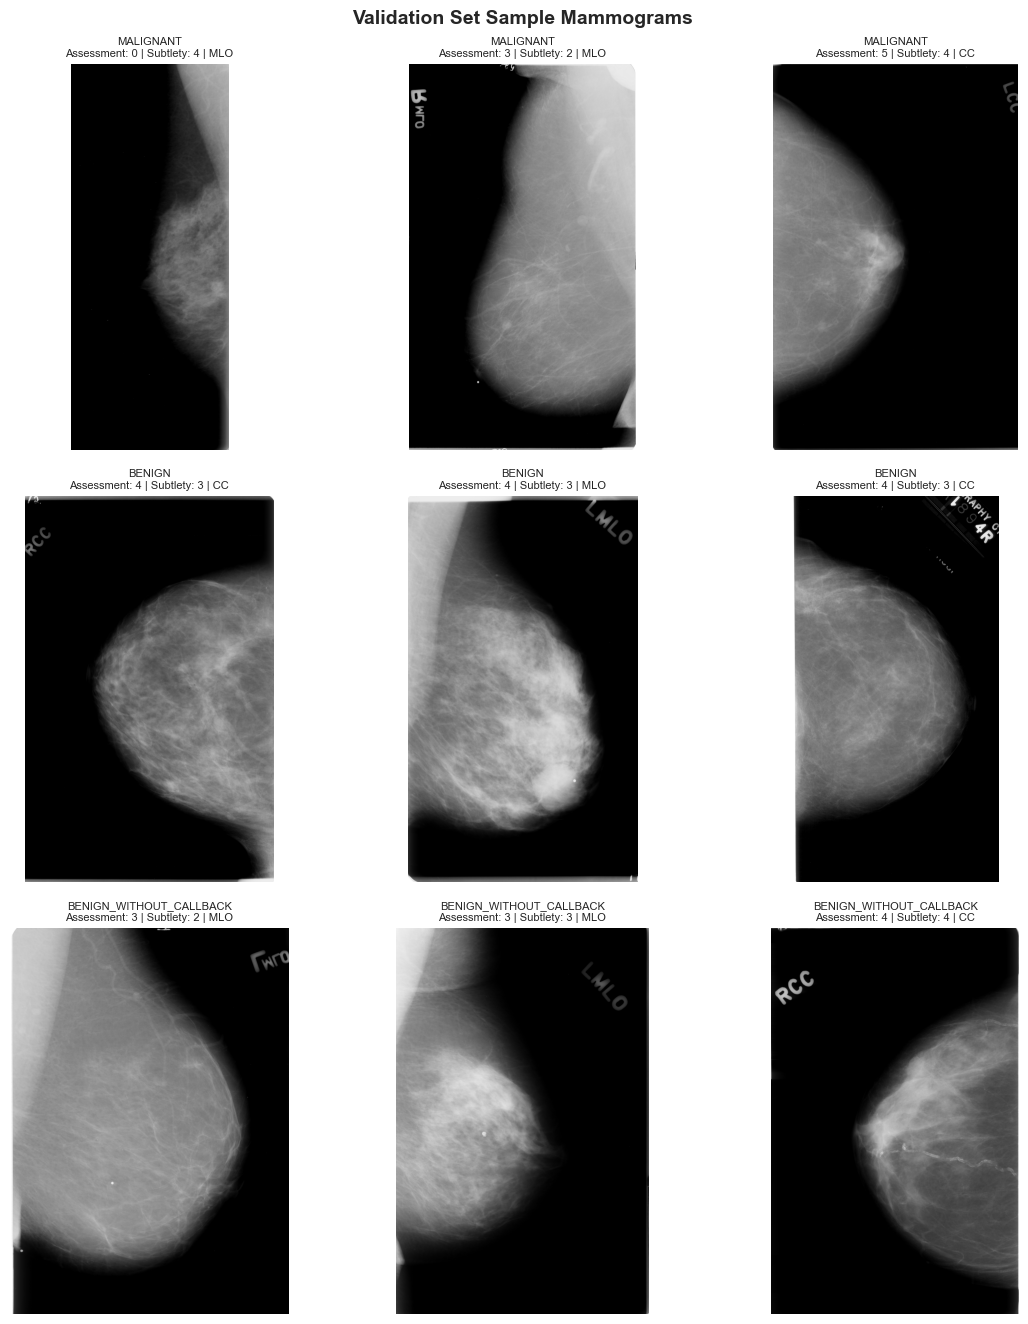

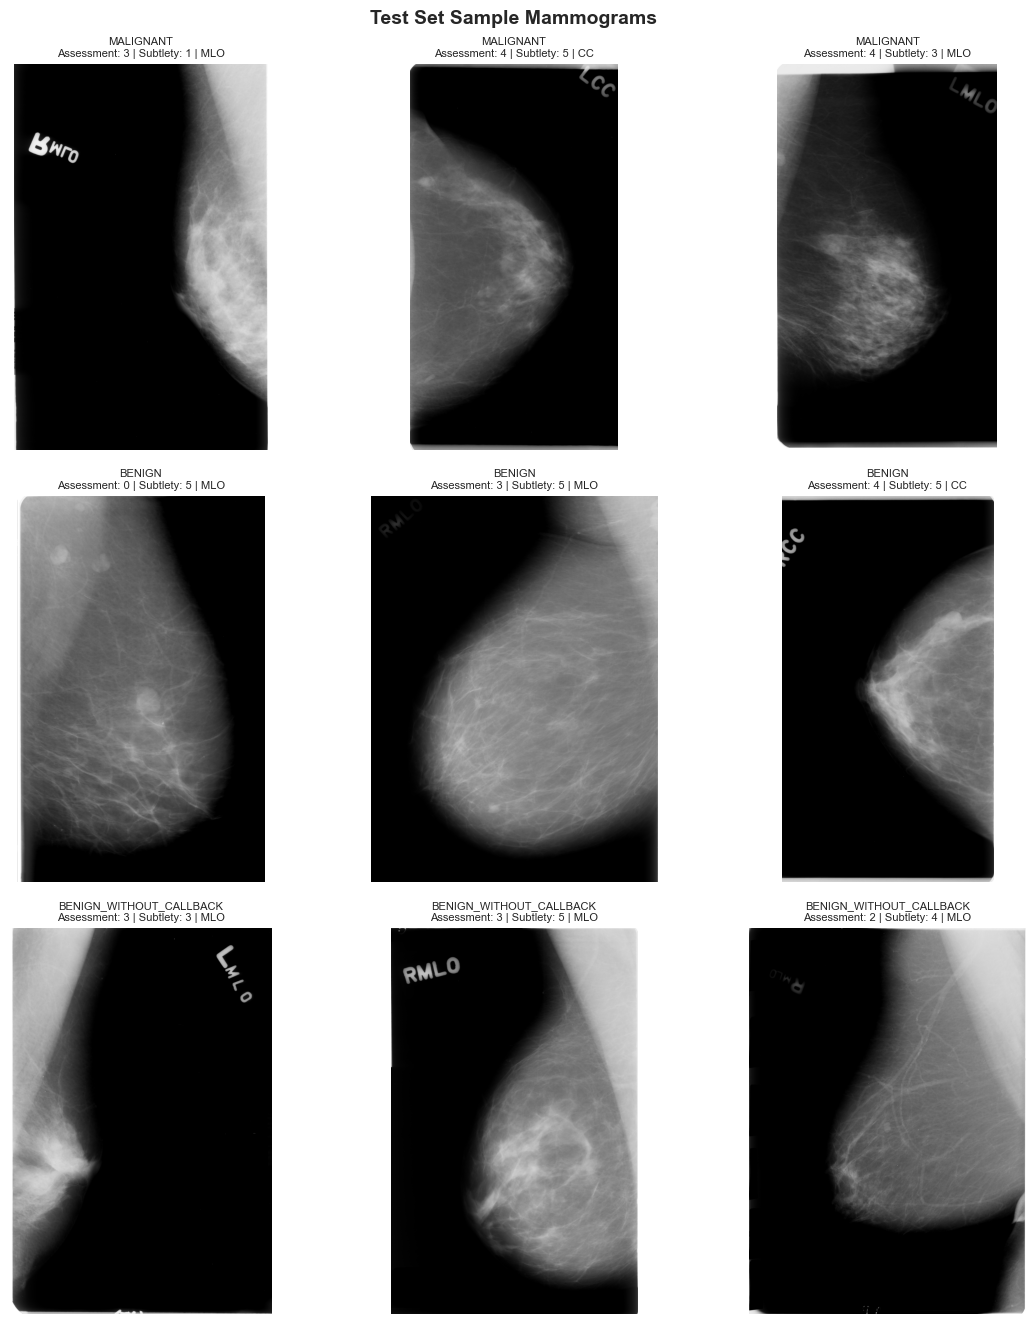

In [14]:
def load_dicom_image(img_dirs: list[Path], csv_path_str: str) -> np.ndarray | None:
    """Load a CBIS-DDSM DICOM by matching parent directory.
    Checks multiple root directories since the dataset is now pooled."""
    
    # Check both Train and Test folders for the image
    for img_dir in img_dirs:
        candidate_dir = img_dir / Path(csv_path_str).parent
        if candidate_dir.exists():
            dcm_files = list(candidate_dir.glob("*.dcm"))
            if dcm_files:
                try:
                    ds = pydicom.dcmread(dcm_files[0], force=True)
                    arr = ds.pixel_array.astype(np.float32)
                    
                    # Invert MONOCHROME1 so high values always map to bright tissue
                    if getattr(ds, "PhotometricInterpretation", "MONOCHROME2") == "MONOCHROME1":
                        arr = arr.max() - arr

                    # Min-max normalisation for display only - pipeline uses global /65,535.
                    if arr.max() > arr.min():
                        arr = (arr - arr.min()) / (arr.max() - arr.min())

                    return arr
                except Exception:
                    continue # Try next file/dir if reading fails
    return None


def show_sample_grid(
    df: pd.DataFrame,
    img_dirs: list[Path],
    n_per_class: int = 3,
    title: str = "Sample Mammograms",
    seed: int = CONFIG["seed"],
) -> None:
    """Display a grid of sample mammograms grouped by pathology class."""
    classes = [
        c
        for c in ["MALIGNANT", "BENIGN", "BENIGN_WITHOUT_CALLBACK"]
        if c in df["pathology"].unique()
    ]

    fig, axes = plt.subplots(
        len(classes),
        n_per_class,
        figsize=(4 * n_per_class, 4.5 * len(classes)),
        squeeze=False,
    )

    for row_idx, cls in enumerate(classes):
        # Deduplicate on image path - one row per DICOM - then sample
        class_df = df[df["pathology"] == cls].drop_duplicates(subset=CONFIG["img_col"])
        subset = class_df.sample(
            n=min(n_per_class, len(class_df)),
            random_state=seed,
        )

        for col_idx, (_, row) in enumerate(subset.iterrows()):
            ax = axes[row_idx][col_idx]
            
            # Pass the list of directories here
            arr = load_dicom_image(img_dirs, row[CONFIG["img_col"]])

            if arr is not None:
                ax.imshow(arr, cmap="gray")
            else:
                ax.text(
                    0.5,
                    0.5,
                    "Image\nnot found",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )

            ax.set_title(
                f"{cls}\n"
                f"Assessment: {row.get('assessment', 'N/A')} | "
                f"Subtlety: {row.get('subtlety', 'N/A')} | "
                f"{row.get('image view', '')}",
                fontsize=8,
            )
            ax.axis("off")

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    fig.savefig(CONFIG["figures_dir"] / f"{title.replace(' ', '_').lower()}.png")
    plt.show()

all_img_dirs = [CONFIG["train_img_dir"], CONFIG["test_img_dir"]]

show_sample_grid(
    train_df,
    all_img_dirs,
    n_per_class=3,
    title="Training Set Sample Mammograms",
)

show_sample_grid(val_df, all_img_dirs, n_per_class=3, title="Validation Set Sample Mammograms")

show_sample_grid(
    test_df, 
    all_img_dirs, 
    n_per_class=3, 
    title="Test Set Sample Mammograms"
)


## 8. DICOM Metadata Audit

Two DICOM attributes must be checked before any preprocessing is designed:

**`PhotometricInterpretation`**: Mammograms can be stored as either `MONOCHROME1` (high pixel value = dark; background is bright) or `MONOCHROME2` (high pixel value = bright; background is dark). If both are present in the dataset without correction, the model trains on contradictory representations of tissue density. `MONOCHROME1` images must be inverted before use.

**`BitsStored`**: CBIS-DDSM images can vary between 12-bit and 16-bit depending on the originating scanner. The audit below confirms the bit depth present in this copy of the dataset, which determines the correct normalisation denominator (4,095 for 12-bit; 65,535 for 16-bit).

Both must be documented here and handled explicitly in `data_loader.py`.

Auditing 1231 train DICOMs...
Auditing 361 test DICOMs...

=== TRAIN SET (1231 images) ===

PhotometricInterpretation:
PhotometricInterpretation
MONOCHROME2    1231

BitsStored:
BitsStored
16    1231

BitsAllocated:
BitsAllocated
16    1231

✓  All images MONOCHROME2 - no inversion required
✓  Uniform bit depth: 16-bit

PixelSpacing tag absent from all audited images


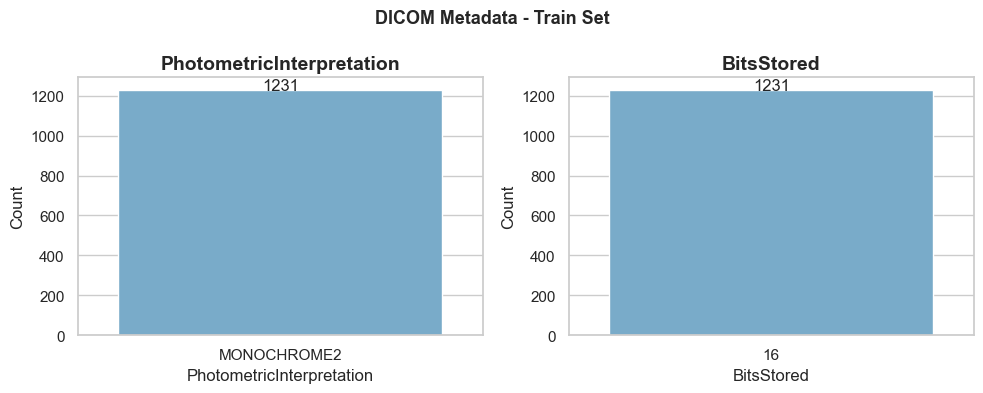


=== TEST SET (361 images) ===

PhotometricInterpretation:
PhotometricInterpretation
MONOCHROME2    361

BitsStored:
BitsStored
16    361

BitsAllocated:
BitsAllocated
16    361

✓  All images MONOCHROME2 - no inversion required
✓  Uniform bit depth: 16-bit

PixelSpacing tag absent from all audited images


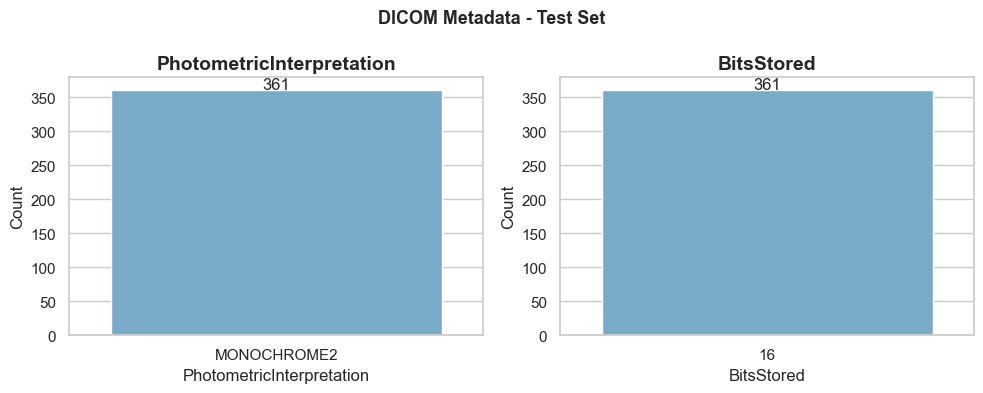

In [15]:
# Full audit using stop_before_pixels - MONOCHROME1 detection is safety-critical.

results = {"train": [], "test": []}

for split_name, img_dir in [
    ("train", CONFIG["train_img_dir"]),
    ("test", CONFIG["test_img_dir"]),
]:
    paths = list(img_dir.glob("**/*.dcm"))
    print(f"Auditing {len(paths)} {split_name} DICOMs...")

    for p in paths:
        try:
            ds = pydicom.dcmread(p, stop_before_pixels=True)
        except Exception as e:
            print(f"  WARNING: could not read {p.name}: {e}")
            continue

        results[split_name].append(
            {
                "path": str(p),
                "PhotometricInterpretation": getattr(
                    ds, "PhotometricInterpretation", "UNKNOWN"
                ),
                "BitsStored": getattr(ds, "BitsStored", "UNKNOWN"),
                "BitsAllocated": getattr(ds, "BitsAllocated", "UNKNOWN"),
                "PixelSpacingRow": (
                    float(ds.PixelSpacing[0]) if hasattr(ds, "PixelSpacing") else None
                ),
                "PixelSpacingCol": (
                    float(ds.PixelSpacing[1]) if hasattr(ds, "PixelSpacing") else None
                ),
                "Rows": int(ds.Rows) if hasattr(ds, "Rows") else None,
                "Columns": int(ds.Columns) if hasattr(ds, "Columns") else None,
            }
        )


for split_name, rows in results.items():
    meta_df = pd.DataFrame(rows)
    print(f"\n=== {split_name.upper()} SET ({len(meta_df)} images) ===")

    print("\nPhotometricInterpretation:")
    print(meta_df["PhotometricInterpretation"].value_counts().to_string())

    print("\nBitsStored:")
    print(meta_df["BitsStored"].value_counts().to_string())

    print("\nBitsAllocated:")
    print(meta_df["BitsAllocated"].value_counts().to_string())

    mono1 = (meta_df["PhotometricInterpretation"] == "MONOCHROME1").sum()
    if mono1 > 0:
        print(f"\n⚠  {mono1} MONOCHROME1 images - inversion required in data_loader.py")
    else:
        print("\n✓  All images MONOCHROME2 - no inversion required")

    if meta_df["BitsStored"].nunique() > 1:
        print(f"⚠  Mixed bit depths: {meta_df['BitsStored'].value_counts().to_dict()}")
    else:
        print(f"✓  Uniform bit depth: {meta_df['BitsStored'].iloc[0]}-bit")

    ps = meta_df[["PixelSpacingRow", "PixelSpacingCol"]].dropna()
    if not ps.empty:
        for dim in ["Row", "Col"]:
            col = f"PixelSpacing{dim}"
            print(
                f"\nPixelSpacing {dim} (mm)  "
                f"mean={ps[col].mean():.4f}  "
                f"std={ps[col].std():.4f}  "
                f"min={ps[col].min():.4f}  "
                f"max={ps[col].max():.4f}"
            )
    else:
        print("\nPixelSpacing tag absent from all audited images")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, col in zip(axes, ["PhotometricInterpretation", "BitsStored"]):
        counts = meta_df[col].value_counts()
        sns.barplot(
            x=counts.index.astype(str),
            y=counts.values,
            hue=counts.index.astype(str),
            palette="Blues_r",
            legend=False,
            ax=ax,
        )
        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Count")
        for i, v in enumerate(counts.values):
            ax.text(i, v + 0.5, str(v), ha="center")
    plt.suptitle(
        f"DICOM Metadata - {split_name.title()} Set", fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    fig.savefig(CONFIG["figures_dir"] / f"dicom_metadata_{split_name}.png")
    plt.show()

## 9. Image Resolution Distribution

CBIS-DDSM mammograms vary substantially in resolution. The distribution here directly informs the resizing strategy in `data_loader.py` and must be reported when justifying the chosen input dimensions to the model.

A common choice in the literature is 224x224 (matching ImageNet input for transfer learning) or 299x299 (InceptionV3). The chosen size should be justified against the median native resolution - aggressive downsampling risks discarding diagnostically relevant fine detail such as microcalcifications (Wang, 2024; Chollet, 2018, Ch. 5).

**Resolution bimodality**: The height distribution shows two distinct clusters, consistent with images acquired from two different scanner types or acquisition protocols across the multiple institutions that contributed to CBIS-DDSM. Different scanners may have different pixel pitch and noise characteristics; the robust augmentation strategy (rotation, brightness variation) partially compensates for this acquisition heterogeneity.

**PixelSpacing tag absent**: The `PixelSpacing` DICOM attribute (physical resolution in mm/pixel) is absent from these images, so lesion size cannot be derived in physical units from DICOM metadata alone. This does not affect the pixel-level classification task but precludes spatial-scale-based feature engineering.

Full audit: 1231 / 1231 training images with resolution data


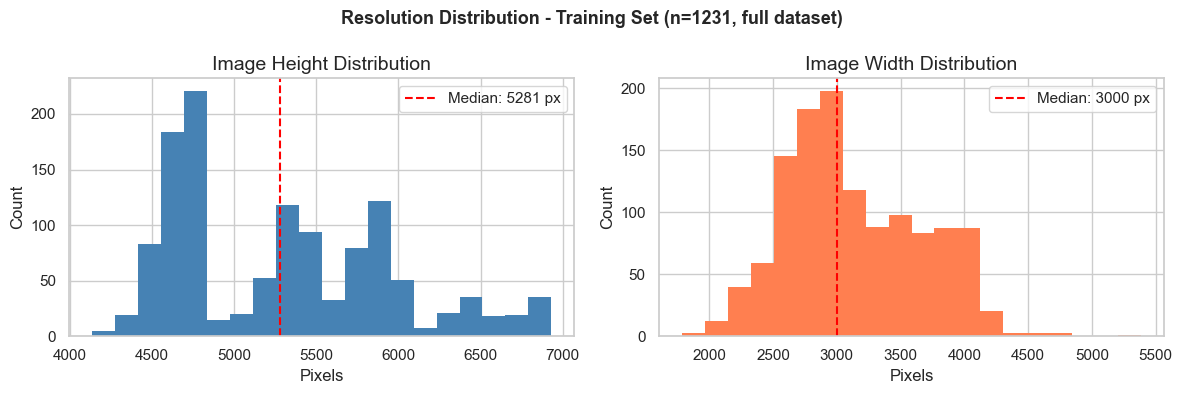

Height - median: 5281 px  |  range: 4136-6931 px
Width  - median: 3000 px  |  range: 1786-5386 px

Downsampling to 224x224:
  Height factor: 23.6x
  Width  factor: 13.4x


In [16]:
# Reuse audit results - no re-reading needed.
_train_meta_full = pd.DataFrame(results["train"])
heights = _train_meta_full["Rows"].dropna().astype(int).tolist()
widths = _train_meta_full["Columns"].dropna().astype(int).tolist()
print(
    f"Full audit: {len(heights)} / {len(_train_meta_full)} training images with resolution data"
)

med_h = np.median(heights)
med_w = np.median(widths)
target_h, target_w = CONFIG["target_size"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, label, colour in [
    (axes[0], heights, "Height", "steelblue"),
    (axes[1], widths, "Width", "coral"),
]:
    med = np.median(vals)
    ax.hist(vals, bins=20, color=colour, edgecolor="none")
    ax.axvline(med, color="red", linestyle="--", label=f"Median: {med:.0f} px")
    ax.set_title(f"Image {label} Distribution")
    ax.set_xlabel("Pixels")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle(
    f"Resolution Distribution - Training Set (n={len(heights)}, full dataset)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "resolution_distribution.png")
plt.show()

print(f"Height - median: {med_h:.0f} px  |  range: {min(heights)}-{max(heights)} px")
print(f"Width  - median: {med_w:.0f} px  |  range: {min(widths)}-{max(widths)} px")
print(f"\nDownsampling to {target_h}x{target_w}:")
print(f"  Height factor: {med_h/target_h:.1f}x")
print(f"  Width  factor: {med_w/target_w:.1f}x")

if "results" in dir() and results["train"]:
    train_meta = pd.DataFrame(results["train"])
    ps = train_meta[["PixelSpacingRow", "PixelSpacingCol"]].dropna()
    if not ps.empty:
        mean_row_mm = ps["PixelSpacingRow"].mean()
        mean_col_mm = ps["PixelSpacingCol"].mean()
        print(
            f"\nAt {target_h}x{target_w} input, each pixel represents approx. "
            f"{mean_row_mm * (med_h / target_h):.2f} x "
            f"{mean_col_mm * (med_w / target_w):.2f} mm of tissue"
        )

_audit_all = pd.concat([pd.DataFrame(results["train"]), pd.DataFrame(results["test"])], ignore_index=True)
mono1_count = (_audit_all["PhotometricInterpretation"] == "MONOCHROME1").sum()
n_audited_total = len(_audit_all)
bits_stored_dict = _audit_all["BitsStored"].value_counts().to_dict()

## 9b. Bimodal Resolution - Scanner-Type Confound Check

Section 9 noted a bimodal height distribution suggesting two scanner types. If scanner type (proxied by height > median) correlates with pathology, it is a confound: the model could learn scanner identity rather than pathology.

In [17]:
# Combine train+test audits - a train_df row can live in either directory.
_audit_train = pd.DataFrame(results["train"])
_audit_train["top_folder"] = _audit_train["path"].apply(
    lambda p: Path(p).parent.relative_to(CONFIG["train_img_dir"]).parts[0])
_audit_test = pd.DataFrame(results["test"])
_audit_test["top_folder"] = _audit_test["path"].apply(
    lambda p: Path(p).parent.relative_to(CONFIG["test_img_dir"]).parts[0])
_meta_combined = pd.concat([_audit_train, _audit_test], ignore_index=True)

# Use all three partitions so the confound check covers the full pooled dataset.
_all_splits = pd.concat([train_df, val_df, test_df], ignore_index=True)
_folder_to_label = (
    _all_splits.assign(top_folder=_all_splits[CONFIG["img_col"]].apply(lambda s: Path(s).parts[0]))
    .groupby("top_folder")["label"].max().to_dict()
)

_scanner_heights, _scanner_labels = [], []
for _row in _meta_combined.itertuples():
    if pd.isna(_row.Rows) or _row.top_folder not in _folder_to_label:
        continue
    _scanner_heights.append(int(_row.Rows))
    _scanner_labels.append(_folder_to_label[_row.top_folder])

_scanner_heights = np.array(_scanner_heights)
_scanner_labels = np.array(_scanner_labels)
_scanner_proxy = (_scanner_heights > np.median(heights)).astype(int)

print(
    f"Matched {len(_scanner_heights)} / {len(_meta_combined)} pooled images to CSV labels"
)

_ct = pd.crosstab(_scanner_proxy, _scanner_labels)
_ct = _ct.rename(
    index={0: "Height ≤ median", 1: "Height > median"},
    columns={0: "Benign", 1: "Malignant"},
)

_chi2, _p, _dof, _ = chi2_contingency(_ct)
_n = _ct.values.sum()
_v = np.sqrt(_chi2 / (_n * (min(_ct.shape) - 1)))
_sig = "***" if _p < 0.001 else ("**" if _p < 0.01 else ("*" if _p < 0.05 else "ns"))

print()
print(_ct.to_string())
print(f"\nChi-square: χ²={_chi2:.2f},  p={_p:.4f},  df={_dof},  V={_v:.3f}  {_sig}")

if _p < 0.05:
    print("\n⚠  Scanner proxy significantly associated with pathology.")
else:
    print("\n✓  No significant association between scanner proxy and pathology.")

Matched 1592 / 1592 pooled images to CSV labels

col_0            Benign  Malignant
row_0                             
Height ≤ median     420        394
Height > median     425        353

Chi-square: χ²=1.35,  p=0.2457,  df=1,  V=0.029  ns

✓  No significant association between scanner proxy and pathology.


## 10. Pixel Intensity Distribution

Pixel statistics are computed from **all 1,134 training images** (the actual train partition post-pooling, streamed one at a time) to provide exact rather than approximate training-set constants, and to confirm the dataset is not trivially separable by global pixel brightness.

**Pixel intensity histogram**: A single-image histogram (below) reveals a characteristic bimodal structure: a large spike near zero (background air pixels) and a broad hump in the ~25,000-45,000 range (breast tissue). Two implications:

1. Tissue pixels do not use the full 16-bit range - the /65,535 global normalisation is slightly conservative but consistent and bias-free across all images.
2. Per-image min-max normalisation would collapse the background spike to exactly 0 and the brightest tissue pixel to exactly 1 - erasing inter-image brightness differences. The global /65,535 scheme preserves these differences.

**Per-class mean intensity**: If malignant and benign images differed substantially in mean brightness, the task would be trivially solved by a single threshold on global intensity. The class-stratified histogram tests this.

Streaming 1134 training DICOMs with 12 threads...
  200/1134 processed  (17%)
  400/1134 processed  (35%)
  600/1134 processed  (52%)
  800/1134 processed  (70%)
  1000/1134 processed  (88%)
  1134/1134 processed  (100%)


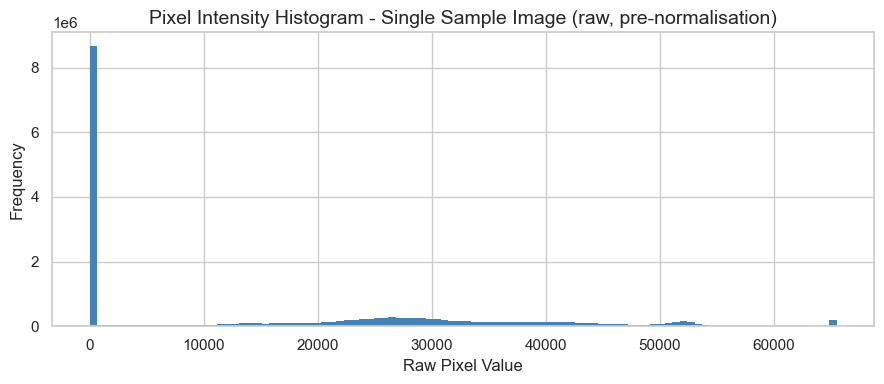

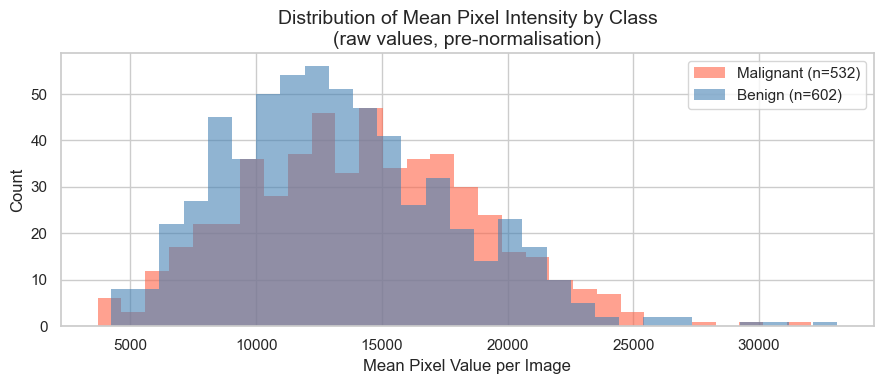

Images loaded: 1134 / 1134 training DICOMs

Global mean (exact) : 13,949.0  raw 16-bit units
Global std  (exact) : 17,372.6  raw 16-bit units

Per-image min  - mean: 0.0  std: 0.0  range: 0-0
Per-image max  - mean: 65022.3  std: 1775.5  range: 49066-65535
Per-image mean - mean: 13732.4  std: 4568.4  range: 3703-33102
Per-image std  - mean: 16459.1  std: 2804.8  range: 8574-24213

Mean pixel intensity - Malignant (n=532): 14220.4 ± 4624.2

Mean pixel intensity - Benign (n=602): 13301.2 ± 4478.2


In [18]:
dir_to_path = {
    p.parent.relative_to(CONFIG["train_img_dir"]): p
    for p in CONFIG["train_img_dir"].glob("**/*.dcm")
}
dir_to_path.update({
    p.parent.relative_to(CONFIG["test_img_dir"]): p
    for p in CONFIG["test_img_dir"].glob("**/*.dcm")
})

_dedup_train = train_df.drop_duplicates(subset=CONFIG["img_col"]).assign(
    _parent=lambda df: df[CONFIG["img_col"]].map(lambda s: Path(s).parent)
)
_label_lookup = dict(zip(_dedup_train["_parent"], _dedup_train["label"]))

def _dicom_stats(args):
    parent_dir, dcm_path, label = args
    try:
        arr = pydicom.dcmread(str(dcm_path), force=True).pixel_array.astype(np.float32)
        return {
            "label": int(label),
            "mean": float(arr.mean()),
            "std": float(arr.std()),
            "min": float(arr.min()),
            "max": float(arr.max()),
            "n_px": int(arr.size),
        }
    except Exception as e:
        print(f"WARNING: {Path(str(dcm_path)).name}: {e}")
        return None

_tasks = [
    (parent_dir, dcm_path, _label_lookup[parent_dir])
    for parent_dir, dcm_path in dir_to_path.items()
    if parent_dir in _label_lookup
]

_N_WORKERS = min(12, len(_tasks))
print(f"Streaming {len(_tasks)} training DICOMs with {_N_WORKERS} threads...")

_raw_results = []
with ThreadPoolExecutor(max_workers=_N_WORKERS) as executor:
    _futures = {executor.submit(_dicom_stats, t): t for t in _tasks}
    for _i, _fut in enumerate(as_completed(_futures), 1):
        _r = _fut.result()
        if _r is not None:
            _raw_results.append(_r)
        if _i % 200 == 0 or _i == len(_tasks):
            print(f"  {_i}/{len(_tasks)} processed  ({100*_i//len(_tasks)}%)")

stats_df = pd.DataFrame(_raw_results)
n_loaded = len(stats_df)

# global_mean = Σ(n_i * mean_i) / Σ(n_i); global_var via law of total variance.
_total_n = int(stats_df["n_px"].sum())
global_mean = float((stats_df["mean"] * stats_df["n_px"]).sum() / _total_n)
_within_var = float((stats_df["n_px"] * stats_df["std"] ** 2).sum() / _total_n)
_between_var = float(
    (stats_df["n_px"] * (stats_df["mean"] - global_mean) ** 2).sum() / _total_n
)
global_std = float(np.sqrt(_within_var + _between_var))

_first_arr = pydicom.dcmread(str(_tasks[0][1]), force=True).pixel_array.astype(
    np.float32
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(_first_arr.flatten(), bins=100, color="steelblue", edgecolor="none")
ax.set_title("Pixel Intensity Histogram - Single Sample Image (raw, pre-normalisation)")
ax.set_xlabel("Raw Pixel Value")
ax.set_ylabel("Frequency")
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "pixel_histogram_single.png")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
for label_val, colour, name in [(1, "tomato", "Malignant"), (0, "steelblue", "Benign")]:
    means = stats_df[stats_df["label"] == label_val]["mean"].values
    ax.hist(
        means,
        bins=30,
        alpha=0.6,
        color=colour,
        label=f"{name} (n={len(means)})",
        edgecolor="none",
    )
ax.set_title(
    "Distribution of Mean Pixel Intensity by Class\n(raw values, pre-normalisation)"
)
ax.set_xlabel("Mean Pixel Value per Image")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "pixel_intensity_by_class.png")
plt.show()

print(f"Images loaded: {n_loaded} / {len(_tasks)} training DICOMs\n")
print(f"Global mean (exact) : {global_mean:,.1f}  raw 16-bit units")
print(f"Global std  (exact) : {global_std:,.1f}  raw 16-bit units")
print()
for stat in ["min", "max", "mean", "std"]:
    vals = stats_df[stat]
    print(
        f"Per-image {stat:4s} - mean: {vals.mean():.1f}  "
        f"std: {vals.std():.1f}  "
        f"range: {vals.min():.0f}-{vals.max():.0f}"
    )

for label_val, name in [(1, "Malignant"), (0, "Benign")]:
    means = stats_df[stats_df["label"] == label_val]["mean"]
    print(
        f"\nMean pixel intensity - {name} (n={len(means)}): "
        f"{means.mean():.1f} ± {means.std():.1f}"
    )

## 10a. Training-Set Normalisation Statistics

Two normalisation strategies are required across the project phases:

1. **Phases 3-5 (training from scratch)**: Divide raw 16-bit pixel values by
   65,535 to produce float32 tensors in [0, 1]. No 8-bit (uint8) conversion is
   performed - uint8 conversion clips values when rescaling 16-bit data to the
   0-255 range, losing precision in high dynamic range regions. The DICOM audit
   (Section 8) confirmed that all 1,134 training images have `BitsStored = 16`,
   so the denominator is fixed at 65,535 across the full dataset.

2. **Phase 6+ (transfer learning)**: Replicate the single grayscale channel to
   three channels (to match ImageNet-pretrained model input shapes), then apply
   the standard ImageNet per-channel normalisation constants (Deng et al., 2009).

Per Chollet (2018, Ch. 5), normalisation statistics must be derived from the
**training set only** and applied unchanged to validation and test sets. Statistics
below are computed from **all 1,134 unique training images** (exact, not a sample)
via the streaming pass in Section 10, using the law of total variance to combine
per-image statistics without loading all images into memory simultaneously.

In [19]:
norm_mean_01 = global_mean / 65535.0
norm_std_01 = global_std / 65535.0

print("=== Training-Set Normalisation Statistics ===")
print(f"\nComputed from : ALL {n_loaded} training images (exact - not a sample)")
print(f"\nRaw 16-bit pixel values:")
print(f"  Global mean   : {global_mean:,.1f}")
print(f"  Global std    : {global_std:,.1f}")
print(f"\nNormalised [0, 1]  (÷ 65,535):")
print(f"  mean  : {norm_mean_01:.4f}")
print(f"  std   : {norm_std_01:.4f}")

# ImageNet constants - replicate grayscale to 3 ch before applying.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

print(f"\nImageNet stats (transfer learning):")
print(f"  mean : {IMAGENET_MEAN}  (R, G, B)")
print(f"  std  : {IMAGENET_STD}  (R, G, B)")

NORM_STATS = {
    "method": "divide_by_max_16bit",
    "divisor": 65535,
    "global_mean_01": round(norm_mean_01, 4),
    "global_std_01": round(norm_std_01, 4),
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
}
print(f"\nNORM_STATS = {NORM_STATS}")
# Verify config.py's NORM_STATS matches the values just computed.
# Guards against stale constants if the split or data changes.
assert abs(config.NORM_STATS["global_mean_01"] - norm_mean_01) < 1e-4, (
    f"config.py mean {config.NORM_STATS['global_mean_01']} != computed {norm_mean_01:.4f}"
)
assert abs(config.NORM_STATS["global_std_01"] - norm_std_01) < 1e-4, (
    f"config.py std {config.NORM_STATS['global_std_01']} != computed {norm_std_01:.4f}"
)
print("✓  config.NORM_STATS matches computed values")

=== Training-Set Normalisation Statistics ===

Computed from : ALL 1134 training images (exact - not a sample)

Raw 16-bit pixel values:
  Global mean   : 13,949.0
  Global std    : 17,372.6

Normalised [0, 1]  (÷ 65,535):
  mean  : 0.2128
  std   : 0.2651

ImageNet stats (transfer learning):
  mean : (0.485, 0.456, 0.406)  (R, G, B)
  std  : (0.229, 0.224, 0.225)  (R, G, B)

NORM_STATS = {'method': 'divide_by_max_16bit', 'divisor': 65535, 'global_mean_01': 0.2128, 'global_std_01': 0.2651, 'imagenet_mean': (0.485, 0.456, 0.406), 'imagenet_std': (0.229, 0.224, 0.225)}
✓  config.NORM_STATS matches computed values


## 10b. Pixel Intensity - Train vs Val vs Test Covariate Shift

Section 10's stats are already train-only by construction post-pooling - the original "full CSV vs train-only" distinction this section drew no longer applies. Repurposed as a covariate-shift check, consistent with Sections 5 and 5b.

Train mean=0.2128, std=0.2651 (n=1134). Val mean=0.2056, std=0.2624 (gap 0.0072). Test mean=0.2238, std=0.2707 (gap 0.0110). Both gaps exceed the 0.002 threshold this section originally used to call differences negligible - there is a modest but real pixel-intensity covariate shift across partitions, on top of the density shift noted in Section 5b.

In [20]:
def _split_pixel_stats(df: pd.DataFrame, name: str) -> dict:
    dirs = {Path(s).parent for s in df[CONFIG["img_col"]]}
    tasks = [(d, dir_to_path[d], 0) for d in dirs if d in dir_to_path]
    rows = []
    with ThreadPoolExecutor(max_workers=_N_WORKERS) as executor:
        futures = {executor.submit(_dicom_stats, t): t for t in tasks}
        for fut in as_completed(futures):
            r = fut.result()
            if r is not None:
                rows.append(r)
    df_ = pd.DataFrame(rows)
    n = int(df_["n_px"].sum())
    mean_ = float((df_["mean"] * df_["n_px"]).sum() / n)
    within = float((df_["n_px"] * df_["std"] ** 2).sum() / n)
    between = float((df_["n_px"] * (df_["mean"] - mean_) ** 2).sum() / n)
    std_ = float(np.sqrt(within + between))
    print(f"{name:<6}: n={len(df_):4d}  mean={mean_/65535:.4f}  std={std_/65535:.4f}")
    return {"mean_01": mean_ / 65535, "std_01": std_ / 65535}

print("=== Pixel Intensity by Split (normalised [0,1]) ===")
print(f"{'Train':<6}: n={n_loaded:4d}  mean={norm_mean_01:.4f}  std={norm_std_01:.4f}")
_val_px = _split_pixel_stats(val_df, "Val")
_test_px = _split_pixel_stats(test_df, "Test")

=== Pixel Intensity by Split (normalised [0,1]) ===
Train : n=1134  mean=0.2128  std=0.2651
Val   : n= 230  mean=0.2056  std=0.2624
Test  : n= 228  mean=0.2238  std=0.2707


## 10c. Augmentation Preview

Visual confirmation that the planned augmentation pipeline produces plausible mammographic variants. These operations will be applied **to training images only** via `tf.keras.layers` augmentation layers or `ImageDataGenerator`.

| Augmentation | Clinically justified? | Rationale |
|---|---|---|
| Horizontal flip | Yes | Mammograms of left and right breasts are mirror images |
| Rotation ±10° | Yes | Accounts for acquisition positioning variation between visits |
| Brightness x0.8-1.2 | Yes | Simulates exposure variation between mammography units |
| Zoom x1.0-1.1 | Yes | Simulates variation in breast compression and positioning |
| **Vertical flip** | **No** | Breasts have a fixed anatomical top/bottom orientation |
| **Shear** | **No** | Distorts lesion morphology, reducing clinical validity |
| **Colour jitter** | **N/A** | Mammograms are grayscale; inapplicable |

The pad-to-square step (Section 9) is applied before any augmentation so that all spatial transforms operate on a square canvas, avoiding inconsistent border artefacts from non-uniform aspect ratios.

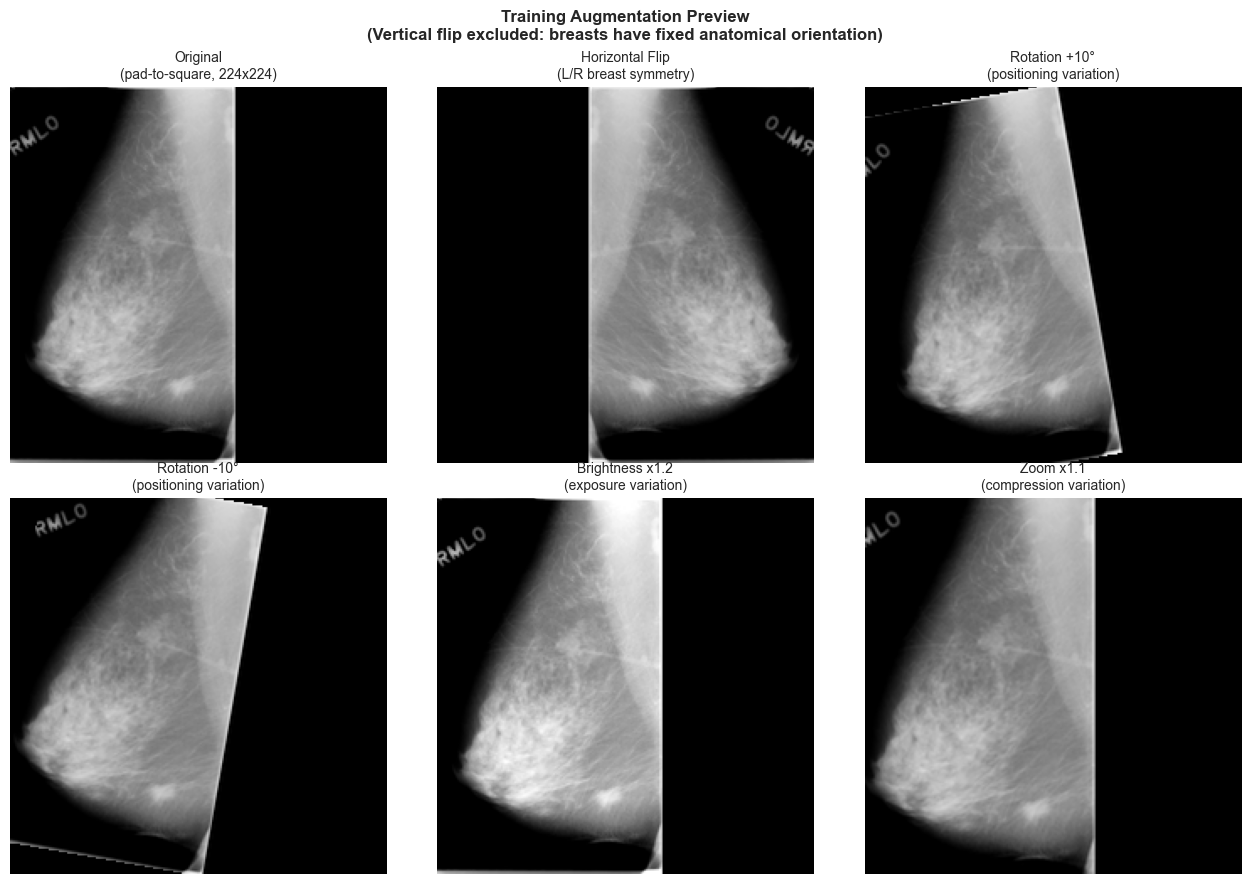

Augmentation preview saved.


In [21]:
# Sample from the logical train partition, not the physical directory,
# since pooling means the physical train dir contains val/test images too.
_rng_aug = np.random.default_rng(CONFIG["seed"])
_aug_csv_path = train_df[CONFIG["img_col"]].iloc[
    int(_rng_aug.integers(len(train_df)))
]
_aug_parent = Path(_aug_csv_path).parent
_aug_path = dir_to_path.get(_aug_parent)
if _aug_path is None:
    print(f"WARNING: could not resolve augmentation preview image: {_aug_parent}")

_ds_aug = pydicom.dcmread(str(_aug_path), force=True)
_raw_aug = _ds_aug.pixel_array.astype(np.float32)
_img_aug = _raw_aug / 65535.0

# Pad to square then resize to target size (matching data_loader.py pipeline).
_target_h, _target_w = CONFIG["target_size"]
_h_aug, _w_aug = _img_aug.shape
_sq_aug = max(_h_aug, _w_aug)
_padded_aug = np.zeros((_sq_aug, _sq_aug), dtype=np.float32)
_padded_aug[:_h_aug, :_w_aug] = _img_aug
_img_resized = (
    np.array(
        _PIL_Image.fromarray((_padded_aug * 255).clip(0, 255).astype(np.uint8)).resize(
            (_target_w, _target_h), _PIL_Image.LANCZOS
        )
    )
    / 255.0
)


def _zoom_centre(img: np.ndarray, factor: float) -> np.ndarray:
    """Centre-crop by 1/factor then resize back - simulates zoom augmentation."""
    h, w = img.shape
    ch, cw = int(h / factor), int(w / factor)
    y0, x0 = (h - ch) // 2, (w - cw) // 2
    cropped = img[y0 : y0 + ch, x0 : x0 + cw]
    return (
        np.array(
            _PIL_Image.fromarray((cropped * 255).clip(0, 255).astype(np.uint8)).resize(
                (w, h), _PIL_Image.LANCZOS
            )
        )
        / 255.0
    )

augmentations = [
    (f"Original\n(pad-to-square, {_target_h}x{_target_w})", _img_resized),
    ("Horizontal Flip\n(L/R breast symmetry)", np.fliplr(_img_resized)),
    (
        "Rotation +10°\n(positioning variation)",
        ndi.rotate(_img_resized, 10, reshape=False, cval=0.0),
    ),
    (
        "Rotation -10°\n(positioning variation)",
        ndi.rotate(_img_resized, -10, reshape=False, cval=0.0),
    ),
    ("Brightness x1.2\n(exposure variation)", np.clip(_img_resized * 1.2, 0, 1)),
    ("Zoom x1.1\n(compression variation)", _zoom_centre(_img_resized, 1.1)),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, (title, aug_img) in zip(axes.flat, augmentations):
    ax.imshow(aug_img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.suptitle(
    "Training Augmentation Preview\n"
    "(Vertical flip excluded: breasts have fixed anatomical orientation)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "augmentation_preview.png")
plt.show()
print("Augmentation preview saved.")

In [22]:
print("=== VALUES FOR SECTION 11 SUMMARY TABLE ===")
print(f"Training rows           : {len(train_df)}")
print(f"Val rows                : {len(val_df)}")
print(f"Test rows               : {len(test_df)}")
print(f"Unique train patients   : {len(train_patients)}")
print(f"Unique val patients     : {len(val_patients)}")
print(f"Unique test patients    : {len(test_patients)}")
print(f"Any patient overlap     : {any_overlap}")
print(f"Imbalance ratio         : {imbalance_ratio:.2f}:1")
print(f"Naive baseline accuracy : {majority_class_acc:.1%}")
print(f"MONOCHROME1 images      : {mono1_count} / {n_audited_total} (full audit)")
print(f"BitsStored distribution : {bits_stored_dict}")
print(f"Median resolution       : {np.median(heights):.0f} x {np.median(widths):.0f} px")
print(f"Unique training images  : {train_df.drop_duplicates(subset=CONFIG['img_col']).shape[0]}")

=== VALUES FOR SECTION 11 SUMMARY TABLE ===
Training rows           : 1134
Val rows                : 230
Test rows               : 228
Unique train patients   : 634
Unique val patients     : 129
Unique test patients    : 129
Any patient overlap     : False
Imbalance ratio         : 1.13:1
Naive baseline accuracy : 53.1%
MONOCHROME1 images      : 0 / 1592 (full audit)
BitsStored distribution : {16: 1592}
Median resolution       : 5281 x 3000 px
Unique training images  : 1134


## 11. EDA Summary

### Dataset characterisation

| Property | Value |
|---|---|
| Dataset | CBIS-DDSM (Lee et al., 2017) - mass cases only, pooled and re-split (Section 1) |
| Task | Binary classification: malignant (1) vs. benign/benign_without_callback (0) |
| Total pooled unique images | 1,592 |
| Train / Val / Test images | 1,134 / 230 / 228 |
| Train / Val / Test patients | 634 / 129 / 129 |
| Patient overlap (all 3 pairs) | 0 - no leakage detected (Section 3) |
| Class imbalance ratio (train) | 1.13:1 (benign:malignant) - near-balanced |
| Naive baseline accuracy (train) | 53.1% |
| BENIGN_WITHOUT_CALLBACK | 91 training cases (8.0%); mapped to label 0 |
| Real-world enrichment | ~72x over-representation of malignancy vs UK NHS screening (~0.65% prevalence) |
| MONOCHROME1 images | 0 / 1,592 (full audit, both CSVs - all MONOCHROME2) |
| Bit depth | 16-bit (BitsStored = 16 across all 1,592 images) |
| Median image resolution | ~5,281 x 3,000 px |
| Normalisation (active) | float32 ÷ 65,535 -> [0, 1] (data_loader.py) |
| Normalisation (train-only stats) | mean=0.2128, std=0.2651 - applied post-augmentation in scratch mode, pre-augmentation no-op in imagenet mode (`data_loader.py`) |
| Pixel-intensity covariate shift | train/val/test means 0.2128/0.2056/0.2238 - exceeds the 0.002 "negligible" threshold (Section 10b) |
| Augmentation pipeline | H-flip, ±10° rotation, brightness ×0.8-1.2 (scratch mode only), zoom-in only to ×1.1 |

### Clinical feature associations (training set)

| Feature | Chi-square | Cramér's V | Mann-Whitney U | Interpretation |
|---|---|---|---|---|
| Mass shape | χ²=299.28*** | V=0.514 (large) | N/A (nominal) | Strong discriminating feature |
| Mass margins | χ²=443.89*** | V=0.637 (large) | N/A (nominal) | Strongest single predictor |
| Assessment | χ²=472.53*** | V=0.646 (large) | r_rb=-0.685*** (large) | BI-RADS score strongly predicts label |
| Subtlety | χ²=32.93*** | V=0.170 (small) | r_rb=-0.108*** (small) | Statistically significant but weak |
| Breast density | χ²=4.42 ns | V=0.062 (negligible) | r_rb=+0.050 ns | No association after case-selection enrichment |

### BI-RADS clinical baseline (Section 5c)

| Metric | BI-RADS ≥ 4 threshold | BI-RADS continuous |
|---|---|---|
| Sensitivity | **0.897** (96 / 107 true cancers detected) | - |
| Specificity | **0.521** (63 / 121 true benigns correctly excluded) | - |
| PPV | 0.623 | - |
| NPV | 0.851 | - |
| Accuracy | 0.697 | - |
| AUC-ROC | - | **0.813 ← binding CNN minimum target** |
| AUC-PR | - | **0.745 ← binding CNN minimum target** |

**CNN must exceed AUC-ROC = 0.813, AUC-PR = 0.745, and Sensitivity = 0.897** to demonstrate clinical utility beyond the radiologist's own BI-RADS assessment.

Radiologist-pathology discordance (test set, n=228): 58 false alarms (BI-RADS ≥ 4, pathology BENIGN; 25.4%) and 0 missed cancers in this split. Missed cancers are a rare nested event (~1.5-3.9% of malignant cases) not controlled by label-level stratification, so they land unevenly across partitions - 17 train, 9 val, 0 test for this seed. Their subtlety (3.82 train, 3.67 val) suggests clinical-judgement discordance more than visual difficulty. Phase 8/9 inspection of these cases should use train/val, not test.


### Multi-view structure (Section 6)

| Split | Complete CC+MLO pairs | Coverage | Paired label distribution |
|---|---|---|---|
| Train | 470 / 664 patient-breast units | **70.8%** | 223 malignant / 247 benign (47.4% mal) |
| Val | 95 / 135 patient-breast units | **70.4%** | 45 malignant / 50 benign (47.4% mal) |
| Test | 95 / 133 patient-breast units | **71.4%** | 45 malignant / 50 benign (47.4% mal) |

Phase 7 dual-stream architecture (Shen et al., 2019) will use the pairing structure prototyped in Section 6.

### Preprocessing implications for `data_loader.py`

1. **Inversion**: All 1,592 pooled images are MONOCHROME2 (full audit, both CSVs). Assert at load time; invert with logging if MONOCHROME1 is encountered (should not occur).

2. **Normalisation**: `pixel_array.astype(np.float32) / 65535.0` -> [0, 1], then standardised with train-set mean/std post-augmentation in scratch mode. No uint8 conversion. For Phase 6 transfer learning: replicate to 3 channels, apply ImageNet stats from `NORM_STATS` (Section 10a). Standardisation applied to all three partitions.

3. **Resize**: Pad-to-square (zero-pad shorter axis), then resize. Direct stretch to 224x224 distorts aspect ratio by ~1.76:1 - would geometrically alter diagnostic features (spiculated margins, mass shape). Pad-then-resize preserves geometry.

4. **Class weights**: Not required (1.13:1 ratio). Sensitivity is the primary metric due to clinical cost asymmetry of missed malignancies, not class imbalance.

5. **Patient stratification**: Pool train+test CSVs, then apply `StratifiedGroupKFold` on `patient_id` for a 70/15/15 train/val/test split. Assert no patient overlap across all three pairs (Section 3).

6. **Augmentation**: Training only - H-flip, ±10° rotation, zoom-in only to x1.1 (both modes); brightness x0.8-1.2 in "scratch" mode only. Vertical flip and shear excluded (no clinical justification).

7. **Deduplication**: Group by image path; `label = max()` (malignant wins) - applied per-CSV before pooling, then defensively re-applied after pooling. Reduces 1,318+378 raw rows to 1,592 unique pooled images.

### Metric interpretation reminder

| Metric | Calibration-free? | Valid for CBIS-DDSM literature comparison? |
|---|---|---|
| Sensitivity / Recall | Yes | Yes - primary metric |
| AUC-ROC | Yes | Yes - primary metric |
| Specificity | Yes | Yes |
| Accuracy | No | With caution (inflation from ~70x enrichment) |
| PPV / Precision | No | No - requires Bayesian recalibration to real-world prevalence |
| AUC-PR | Yes | Yes - primary metric (more informative under class imbalance) |

### Known limitations

- CBIS-DDSM is derived from 1990s-2000s film-screen mammography. Domain shift to modern FFDM systems is a fundamental generalisability concern (Wang, 2024).
- Mass cases only - calcifications excluded.
- ~72x malignancy enrichment vs real-world UK NHS screening limits clinical metric interpretation (accuracy, PPV not directly transferable).
- Aggressive downsampling from median ~5,281 x 3,000 px to 224x224 (height factor 23.6x, width factor 13.4x) loses significant spatial detail; a key methodological limitation to discuss in the report. 
- Dataset size is modest relative to state-of-the-art published models.
- Bimodal height distribution suggests two scanner types; chi-square test confirms scanner type is not confounded with pathology (χ²=1.35, p=0.246, ns, n=1,592 - Section 9b, full pooled dataset).
- Density distribution is broadly stable across train/val/test (D1: 18.1/19.6/17.5%, D2: 44.1/45.2/49.1%, D3: 28.3/23.0/26.8%, D4: 9.5/12.2/6.6%) - D4's test-set dip is the largest remaining shift; Phase 9 evaluation should still stratify by density.
- Pixel-intensity covariate shift is real, not negligible: train/val/test means are 0.2128/0.2056/0.2238 - both val and test gaps exceed the 0.002 threshold this project uses elsewhere for "negligible" (Section 10b). Worth monitoring in Phase 9 if val/test performance diverges from train.
- Missed-cancer discordance (BI-RADS ≤ 2, pathology malignant) is a rare nested event not controlled by label-level stratification: 17/1,134 train, 9/230 val, 0/228 test for this split/seed - a property of the split, not evidence the dataset lacks such cases (Section 5c).

### Chollet Stages 1-3 completed in this notebook

- Stage 1 (define problem + dataset): binary classification on CBIS-DDSM mass cases
- Stage 2 (success measure): co-primary metrics are sensitivity, AUC-ROC, and AUC-PR - all calibration-free and valid for literature comparison. Binding CNN targets from BI-RADS clinical baseline (Section 5c, test set): AUC-ROC > 0.813, AUC-PR > 0.745, Sensitivity > 0.897.
- Stage 3 (evaluation protocol): pooled + StratifiedGroupKFold patient-level 70/15/15 split, zero patient overlap enforced across all three pairs (Sections 3, 3b)